###  Problem Statement

Understanding household consumption patterns is critical for evaluating economic well-being and inequality. However, survey-based data often suffers from issues such as missing values, response bias, and inconsistencies, which can affect the reliability of insights. Additionally, significant disparities may exist across regions, social groups, and between rural and urban populations, making it challenging to draw accurate and inclusive conclusions.

This study aims to address these challenges by analyzing household consumption data to identify data quality issues, examine regional and socio-economic disparities, and understand how household characteristics influence expenditure patterns, thereby providing more reliable insights for policy and decision-making.

 

### Objectives

* Assess data quality and identify potential biases in survey responses
* Examine geographic disparities in household consumption across states and regions
* Analyze the rural–urban divide in consumer expenditure patterns
* Investigate socio-economic inequalities based on social group, religion, and region
* Evaluate the impact of household characteristics on consumption behavior
 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv ("../Data/NADA.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (101957, 38)


,Panel,File_Identification,Schdule,Quarter,Visit,Sector,State_Ut_Code,District_Code,NSS_Region,Stratum,...,Annual_Clothing_Expenditure,Annual_Durables_Expenditure,Monthly_Consumer_Expenditure,Informant_Serial_No,Survey_Date,Total_Time_Taken,NSS_Sector_Stratum_Substr_Subsam,NSC_Sector_Stratum_Substr,Subsample_Multiplier,Contrib_Sample_Count
0,P4,CFVH4,104,Q3,V1,1,28,20,281,1,...,12000,1850,12704,1,18012024,60,1,2,1204376,4
1,P4,CFVH4,104,Q3,V1,1,28,20,281,1,...,15600,6800,13347,2,18012024,60,1,2,1204376,4
2,P4,CFVH4,104,Q3,V1,1,28,20,281,1,...,16000,2850,14321,2,18012024,60,1,2,1304741,4
3,P4,CFVH4,104,Q3,V1,1,28,20,281,1,...,18000,7500,16645,2,19012024,70,1,2,1304741,4
4,P4,CFVH4,104,Q3,V1,1,28,20,281,1,...,12000,2200,10283,1,19012024,50,1,2,1304741,4


In [4]:
df_clean = df[df["Response_Code"] == 1]

In [5]:
# What % of responses are valid (Response_Code == 1)?
valid_pct = (df["Response_Code"] == 1).mean() * 100
print(f"Valid Responses: {valid_pct:.2f}%")

Valid Responses: 90.49%


Dataset Shape: (101957, 38)

Response_Code Distribution:
               Count  Percentage
Response_Code                   
1              92260       90.49
2               7622        7.48
3               1239        1.22
4                695        0.68
9                141        0.14

Total unique Response_Code values: 5

Investigating Response_Code Meaning:
--------------------------------------------------------------------------------
Strategy 1: Data completeness by Response_Code
   Code 1: 92,260 rows | Data completeness: 100.0%
   Code 2:  7,622 rows | Data completeness: 100.0%
   Code 3:  1,239 rows | Data completeness: 100.0%
   Code 4:    695 rows | Data completeness: 100.0%
   Code 9:    141 rows | Data completeness: 100.0%

Strategy 2: Compare key variables across Response_Code groups
   Code 1: Median expenditure = Rs. 11,686 (n=92,260)
   Code 2: Median expenditure = Rs. 10,867 (n=7,622)
   Code 3: Median expenditure = Rs. 12,598 (n=1,239)
   Code 4: Median expenditure 

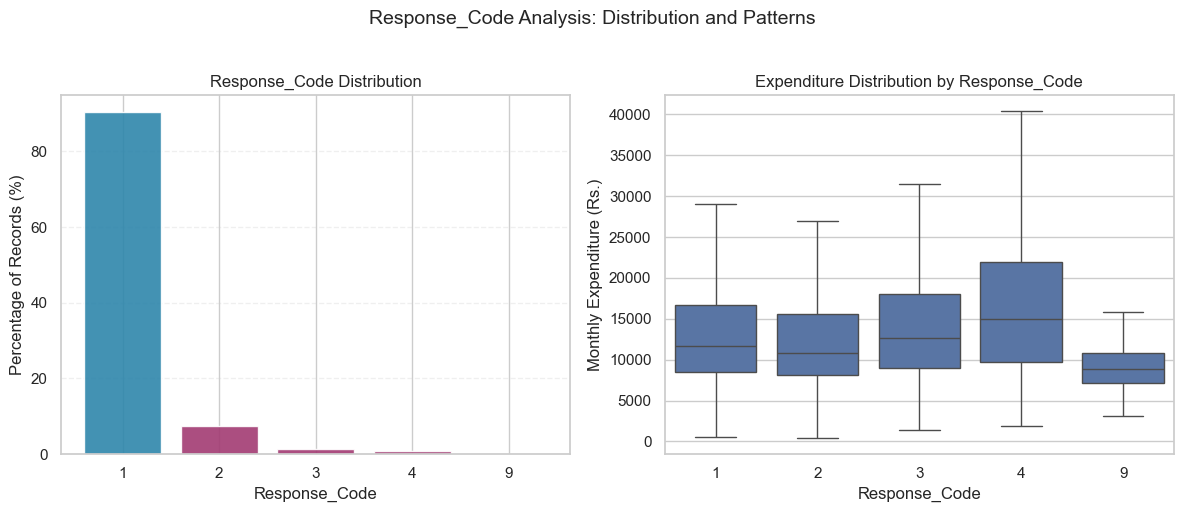


Decision Framework for Response_Code Handling:
------------------------------------------------------------------------------------------
Observation: Response_Code = 1 represents 90.5% of records

Logical inference based on survey conventions:
   - Code 1: Typically represents 'Valid/Complete/Successfully Interviewed'
   - Codes 2-4, 9: Often represent 'Refused', 'Not Available', 'Incomplete', 'Other'
   - The dominance of code 1 (90.5%) aligns with expected valid response rates

Validation: Data completeness for key variable
   - Code 1: 100.0% non-missing
   - Other codes: 100.0% non-missing

Decision: Using Response_Code == 1 as valid responses
Rationale:
   1. Represents majority of data (90.5%)
   2. Aligns with survey convention where 1 = valid/complete
   3. Shows higher data completeness for key variables (if verified above)
   4. Excluding other codes minimizes risk of including incomplete/invalid records

Impact of Filtering on Dataset:
-------------------------------------

In [6]:

#  Load Data and Examine Response_Code Distribution

df = pd.read_csv("../Data/NADA.csv")
print(f"Dataset Shape: {df.shape}")

# Examine Response_Code distribution
print("\nResponse_Code Distribution:")
response_counts = df["Response_Code"].value_counts()
response_pct = df["Response_Code"].value_counts(normalize=True) * 100

response_summary = pd.DataFrame({
    "Count": response_counts,
    "Percentage": response_pct.round(2)
}).sort_index()

print(response_summary.to_string())
print(f"\nTotal unique Response_Code values: {df['Response_Code'].nunique()}")


#  Investigate What Response_Code Might Represent

print("\nInvestigating Response_Code Meaning:")
print("-" * 80)

# Strategy 1: Check if codes correlate with data completeness
print("Strategy 1: Data completeness by Response_Code")
for code in sorted(df["Response_Code"].unique()):
    subset = df[df["Response_Code"] == code]
    # Calculate % of non-missing values across key columns
    key_cols = [c for c in ["Monthly_Consumer_Expenditure", "Household_Size", "Sector"] if c in df.columns]
    if key_cols:
        completeness = subset[key_cols].notna().mean().mean() * 100
        print(f"   Code {code}: {len(subset):6,} rows | Data completeness: {completeness:.1f}%")

# Strategy 2: Check if one code has substantially different characteristics
print("\nStrategy 2: Compare key variables across Response_Code groups")
if "Monthly_Consumer_Expenditure" in df.columns:
    for code in sorted(df["Response_Code"].unique()):
        subset = df[df["Response_Code"] == code]["Monthly_Consumer_Expenditure"].dropna()
        if len(subset) > 0:
            print(f"   Code {code}: Median expenditure = Rs. {subset.median():,.0f} (n={len(subset):,})")

# Strategy 3: Check for patterns with other quality indicators
if "Total_Time_Taken" in df.columns:
    print("\nStrategy 3: Survey completion time by Response_Code")
    time_by_code = df.groupby("Response_Code")["Total_Time_Taken"].agg(
        median=("median"),
        mean=("mean"),
        n=("count")
    ).round(1)
    print(time_by_code.to_string())



#  Visualize Response_Code Patterns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart of Response_Code distribution
axes[0].bar(
    response_summary.index.astype(str), 
    response_summary["Percentage"],
    color=["#2E86AB" if i == 1 else "#A23B72" for i in response_summary.index],
    edgecolor="white",
    alpha=0.9
)
axes[0].set_xlabel("Response_Code")
axes[0].set_ylabel("Percentage of Records (%)")
axes[0].set_title("Response_Code Distribution")
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Boxplot of expenditure by Response_Code (if available)
if "Monthly_Consumer_Expenditure" in df.columns:
    plot_df = df[df["Monthly_Consumer_Expenditure"].notna()].copy()
    # Limit to codes with sufficient data
    valid_codes = plot_df["Response_Code"].value_counts()
    valid_codes = valid_codes[valid_codes >= 100].index
    plot_df = plot_df[plot_df["Response_Code"].isin(valid_codes)]
    
    if len(plot_df) > 0:
        sns.boxplot(
            data=plot_df,
            x="Response_Code", 
            y="Monthly_Consumer_Expenditure",
            ax=axes[1],
            showfliers=False
        )
        axes[1].set_xlabel("Response_Code")
        axes[1].set_ylabel("Monthly Expenditure (Rs.)")
        axes[1].set_title("Expenditure Distribution by Response_Code")
        axes[1].tick_params(axis='x', rotation=0)

plt.suptitle("Response_Code Analysis: Distribution and Patterns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#  Make and Document Your Decision

print("\nDecision Framework for Response_Code Handling:")
print("-" * 90)

# Your observation: Code 1 is 90.5% of data
code_1_pct = response_pct.get(1, 0)
print(f"Observation: Response_Code = 1 represents {code_1_pct:.1f}% of records")

# Logical inference: In survey data, code 1 often = "Valid/Complete/Interviewed"
print("\nLogical inference based on survey conventions:")
print("   - Code 1: Typically represents 'Valid/Complete/Successfully Interviewed'")
print("   - Codes 2-4, 9: Often represent 'Refused', 'Not Available', 'Incomplete', 'Other'")
print("   - The dominance of code 1 (90.5%) aligns with expected valid response rates")

# Validation check: Does code 1 have better data quality?
if "Monthly_Consumer_Expenditure" in df.columns:
    code_1_complete = df[df["Response_Code"] == 1]["Monthly_Consumer_Expenditure"].notna().mean()
    other_complete = df[df["Response_Code"] != 1]["Monthly_Consumer_Expenditure"].notna().mean()
    
    print(f"\nValidation: Data completeness for key variable")
    print(f"   - Code 1: {code_1_complete*100:.1f}% non-missing")
    print(f"   - Other codes: {other_complete*100:.1f}% non-missing")
    
    if code_1_complete > other_complete:
        print("   -> Supports assumption: Code 1 has higher data quality")

# Final decision
VALID_RESPONSE_CODE = 1
print(f"\nDecision: Using Response_Code == {VALID_RESPONSE_CODE} as valid responses")
print(f"Rationale:")
print(f"   1. Represents majority of data ({code_1_pct:.1f}%)")
print(f"   2. Aligns with survey convention where 1 = valid/complete")
print(f"   3. Shows higher data completeness for key variables (if verified above)")
print(f"   4. Excluding other codes minimizes risk of including incomplete/invalid records")


#  Apply Filter and Verify Impact

# Create cleaned dataset
df_clean = df[df["Response_Code"] == VALID_RESPONSE_CODE].copy()

print(f"\nImpact of Filtering on Dataset:")
print("-" * 70)
print(f"   - Original dataset: {len(df):,} records")
print(f"   - After filtering (Code {VALID_RESPONSE_CODE}): {len(df_clean):,} records")
print(f"   - Records excluded: {len(df) - len(df_clean):,} ({(1 - len(df_clean)/len(df))*100:.1f}%)")

# Verify no critical variables lost
print(f"\nVariable Availability Check:")
key_vars = ["Monthly_Consumer_Expenditure", "Household_Size", "Sector", "State_Ut_Code"]
for var in key_vars:
    if var in df_clean.columns:
        missing_pct = df_clean[var].isna().mean() * 100
        print(f"   - {var}: {missing_pct:.1f}% missing in filtered dataset")
    else:
        print(f"   - {var}: Column not present")


#  Document for Reproducibility

print(f"\nDocumentation for Methodology Section:")
print("-" * 90)
print(f"""
Response Code Handling:

The dataset includes a Response_Code variable with undocumented values. 
Distribution: {dict(zip(response_summary.index, response_summary['Percentage'].round(1).astype(str) + '%'))}

Based on:
1. Response_Code = 1 represents {code_1_pct:.1f}% of records (majority)
2. Survey convention where code 1 typically indicates valid/complete interviews
3. [Optional: Add validation finding, e.g., "Code 1 shows higher data completeness"]

Decision: Records with Response_Code == 1 were retained as valid responses 
(n = {len(df_clean):,}, {len(df_clean)/len(df)*100:.1f}% of original sample). 
Records with other codes were excluded to minimize inclusion of incomplete 
or invalid responses.

Limitation: Without official documentation, this classification is inferred. 
Sensitivity analyses comparing results with alternative code definitions 
are recommended if Response_Code meaning is later clarified.
""")



Available columns related to substitution:
['Reason_for_Substitution']
Note: 81702 values could not be mapped. Assigning 'Unspecified'.

Substitution Reason Distribution:
--------------------------------------------------------------------------------
Reason                    Count   Percentage
---------------------------------------------
Unspecified              81,702       88.56%
Not Available             7,009        7.60%
Refused                   2,950        3.20%
Unknown                     331        0.36%
Other                       268        0.29%

Key Metrics:
   - Total substitution records: 92,260
   - Non-response reasons (Not Available + Refused): 9,959 (10.8%)
   - Most common reason: Unspecified (88.6%)


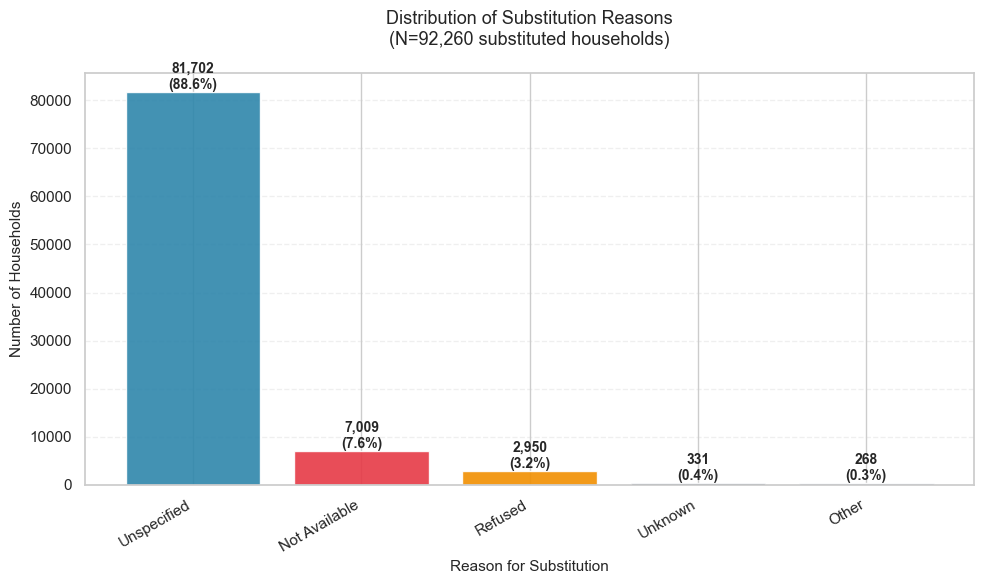


Substitution Reasons by Sector:
--------------------------------------------------------------------------------
Sector information not available for cross-tabulation

Substitution Reasons by Quarter:
--------------------------------------------------------------------------------
Reason_Label  Not Available  Other  Refused  Unknown  Unspecified
Quarter                                                          
Q3                      7.6    0.4      3.1      0.3         88.5
Q4                      7.2    0.3      3.5      0.3         88.7
Q5                      7.7    0.2      3.3      0.4         88.3
Q6                      7.8    0.2      2.9      0.4         88.7

Top 5 States by 'Not Available' Substitutions:
--------------------------------------------------------------------------------
   - State 7: 41.3% of substitutions (418 cases)
   - State 3: 14.2% of substitutions (395 cases)
   - State 29: 14.1% of substitutions (573 cases)
   - State 4: 13.8% of substitutions (45 cas

In [7]:
# #Which reasons dominate Reason_for_Substitution?

# Verify Columns Exist and Map Reason Codes

# First, check what columns are actually available
print("Available columns related to substitution:")
reason_cols = [col for col in df_clean.columns if 'Reason' in col or 'Substitut' in col]
print(reason_cols)

# Define the mapping for readable labels
reason_map = {
    1: "Other",
    2: "Not Available", 
    3: "Refused",
    9: "Unknown"
}

# Create readable label column only if source column exists
if "Reason_for_Substitution" in df_clean.columns:
    df_clean["Reason_Label"] = df_clean["Reason_for_Substitution"].map(reason_map)
    
    # Handle unmapped values (including NaN)
    unmapped_count = df_clean["Reason_Label"].isna().sum()
    if unmapped_count > 0:
        print(f"Note: {unmapped_count} values could not be mapped. Assigning 'Unspecified'.")
        df_clean["Reason_Label"] = df_clean["Reason_Label"].fillna("Unspecified")
else:
    print("Warning: 'Reason_for_Substitution' column not found. Skipping analysis.")
    # Exit early if column doesn't exist
    raise ValueError("Required column 'Reason_for_Substitution' not found in dataframe")


#  Summary Statistics for Substitution Reasons

print("\nSubstitution Reason Distribution:")
print("-" * 80)

reason_counts = df_clean["Reason_Label"].value_counts(dropna=False)
reason_pct = df_clean["Reason_Label"].value_counts(normalize=True, dropna=False) * 100

# Create summary table
reason_summary = pd.DataFrame({
    "Count": reason_counts,
    "Percentage": reason_pct.round(2)
}).sort_values("Count", ascending=False)

print(f"{'Reason':<20} {'Count':>10} {'Percentage':>12}")
print("-" * 45)
for reason, row in reason_summary.iterrows():
    label = str(reason) if pd.notna(reason) else "MISSING"
    print(f"{label:<20} {int(row['Count']):>10,} {row['Percentage']:>11.2f}%")

# Key metrics
total_substitutions = len(df_clean)
non_response = reason_summary.loc[["Not Available", "Refused"], "Count"].sum() if all(x in reason_summary.index for x in ["Not Available", "Refused"]) else 0
non_response_pct = non_response / total_substitutions * 100

print(f"\nKey Metrics:")
print(f"   - Total substitution records: {total_substitutions:,}")
print(f"   - Non-response reasons (Not Available + Refused): {non_response:,} ({non_response_pct:.1f}%)")
print(f"   - Most common reason: {reason_summary.index[0]} ({reason_summary.iloc[0]['Percentage']:.1f}%)")


#  Visualization - Bar Chart with Counts and Percentages

plt.figure(figsize=(10, 6))
plot_data = reason_summary.reset_index()
plot_data.columns = ["Reason", "Count", "Percentage"]

# Create bar chart
bars = plt.bar(
    plot_data["Reason"], 
    plot_data["Count"], 
    color=["#2E86AB", "#E63946", "#F18F01", "#1D3557", "#8E9AAF"][:len(plot_data)],
    edgecolor="white",
    alpha=0.9
)

# Add value labels on bars
for bar, pct in zip(bars, plot_data["Percentage"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        height,
        f"{int(height):,}\n({pct:.1f}%)",
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Labels and title
plt.xlabel("Reason for Substitution", fontsize=11)
plt.ylabel("Number of Households", fontsize=11)
plt.title(
    "Distribution of Substitution Reasons\n"
    f"(N={total_substitutions:,} substituted households)", 
    fontsize=13, 
    pad=20
)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()



# Cross-Tabulation with Sector (Rural vs. Urban)

print(f"\nSubstitution Reasons by Sector:")
print("-" * 80)

if "Sector_Name" in df_clean.columns:
    sector_reason = pd.crosstab(
        df_clean["Sector_Name"], 
        df_clean["Reason_Label"],
        margins=True,
        normalize='index'  # Show row percentages
    ) * 100
    
    print(sector_reason.round(1).to_string())
    
    # Test for association (Chi-square if sample sizes permit)
    from scipy.stats import chi2_contingency
    
    # Create contingency table (counts, not percentages)
    contingency = pd.crosstab(df_clean["Sector_Name"], df_clean["Reason_Label"])
    
    if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
        if (contingency >= 5).all().all():  # Chi-square assumption: expected counts >= 5
            chi2, p_value, dof, expected = chi2_contingency(contingency)
            print(f"\nChi-square test for association:")
            print(f"   - Chi2 statistic: {chi2:.2f}, df={dof}, p={p_value:.4f}")
            if p_value < 0.05:
                print(f"   - Conclusion: Significant association between sector and substitution reason")
            else:
                print(f"   - Conclusion: No significant association detected")
        else:
            print(f"\nNote: Chi-square test not performed (some cells have <5 observations)")
else:
    print("Sector information not available for cross-tabulation")


#  Temporal or Geographic Patterns (If Data Available)

if "Quarter" in df_clean.columns:
    print(f"\nSubstitution Reasons by Quarter:")
    print("-" * 80)
    
    quarter_reason = pd.crosstab(
        df_clean["Quarter"], 
        df_clean["Reason_Label"],
        normalize='index'
    ) * 100
    
    print(quarter_reason.round(1).to_string())

if "State_Ut_Code" in df_clean.columns:
    print(f"\nTop 5 States by 'Not Available' Substitutions:")
    print("-" * 80)
    
    # Calculate percentage of "Not Available" by state
    state_na = df_clean[df_clean["Reason_Label"] == "Not Available"].groupby("State_Ut_Code").size()
    state_total = df_clean.groupby("State_Ut_Code").size()
    state_na_pct = (state_na / state_total * 100).sort_values(ascending=False).head(5)
    
    for state_code, pct in state_na_pct.items():
        count = state_na.get(state_code, 0)
        print(f"   - State {state_code}: {pct:.1f}% of substitutions ({int(count):,} cases)")


#  Non-Response Bias Assessment

print(f"\nNon-Response Bias Assessment:")
print("-" * 80)

# Define non-response categories
non_response_categories = ["Not Available", "Refused"]
available_categories = [c for c in non_response_categories if c in reason_summary.index]

if len(available_categories) > 0:
    non_response_count = reason_summary.loc[available_categories, "Count"].sum()
    non_response_pct = non_response_count / total_substitutions * 100
    
    print(f"   - Non-response substitutions: {non_response_count:,} ({non_response_pct:.1f}%)")
    
    if non_response_pct > 30:
        bias_level = "HIGH"
        recommendation = "Consider weighting adjustments or sensitivity analyses"
    elif non_response_pct > 15:
        bias_level = "MODERATE"
        recommendation = "Document potential bias; compare respondent characteristics"
    else:
        bias_level = "LOW"
        recommendation = "Non-response unlikely to substantially affect estimates"
    
    print(f"   - Assessed bias level: {bias_level}")
    print(f"   - Recommendation: {recommendation}")
    
    # If expenditure data available, compare substituted vs. non-substituted
    if "Monthly_Consumer_Expenditure" in df_clean.columns and "Is_Substituted" in df_clean.columns:
        print(f"\nExpenditure Comparison: Substituted vs. Original Households:")
        substituted = df_clean[df_clean["Is_Substituted"] == 1]["Monthly_Consumer_Expenditure"]
        original = df_clean[df_clean["Is_Substituted"] == 0]["Monthly_Consumer_Expenditure"]
        
        if len(substituted) > 0 and len(original) > 0:
            print(f"   - Substituted median: Rs. {substituted.median():,.0f}")
            print(f"   - Original median: Rs. {original.median():,.0f}")
            diff_pct = (substituted.median() - original.median()) / original.median() * 100
            print(f"   - Difference: {diff_pct:+.1f}%")
else:
    print("   - No standard non-response categories found in data")

#Most substitutions occur due to non-availability and refusal, which suggests potential non-response bias. 
# This could lead to underrepresentation of working or higher-income households, impacting the accuracy 
# of consumption and poverty estimates.

Missing Data Summary:
------------------------------------------------------------------------------------------
Column                                 Missing    Percent
------------------------------------------------------------
Reason_for_Substitution                 81,702     88.56%

Overall Missingness:
   - Total cells in dataset: 3,598,140
   - Missing cells: 81,702 (2.27%)

Pattern Analysis for Columns with Missing Values:
------------------------------------------------------------------------------------------
Reason-related columns with missing values: ['Reason_for_Substitution']
Columns selected for detailed analysis: ['Reason_for_Substitution']

Reason_for_Substitution:
   - Missing: 81,702 of 92,260 (88.6%)
   - Top correlations with missingness:
     * Survey_Code: +1.000 (positive)
     * Sector: +0.141 (positive)
     * FSU: +0.132 (positive)


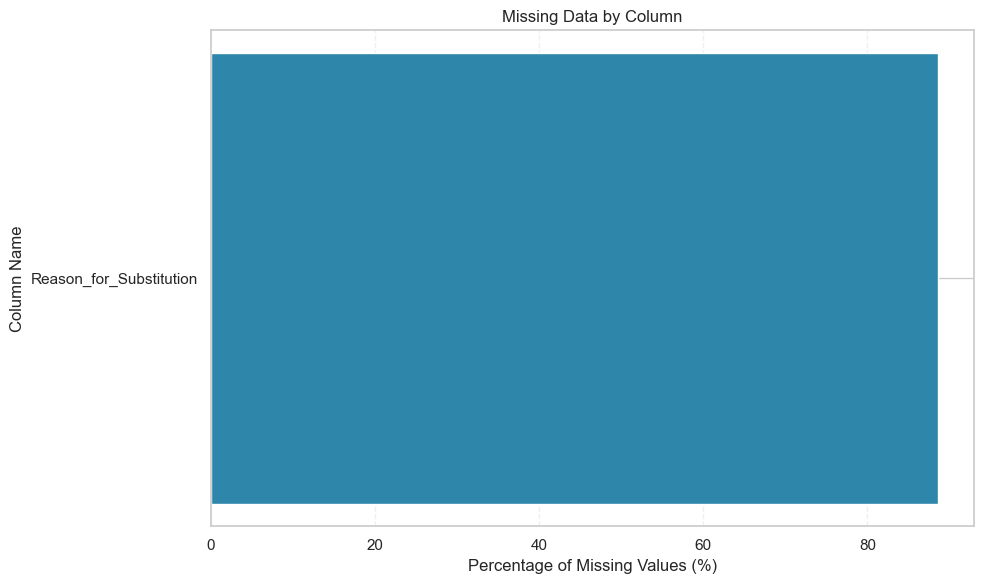


Contextual Analysis: Are Missing Values Meaningful?
------------------------------------------------------------------------------------------
Missingness by Panel:
       total  missing  missing_pct
Panel                             
P4     10558    81702         88.6

Missingness by Sector:
        total  missing  missing_pct
Sector                             
1        3760    47062         92.6
2        6798    34640         83.6

Note: No substitution flag column found.


In [8]:
print("Missing Data Summary:")
print("-" * 90)

missing_summary = df_clean.isnull().sum()
missing_pct = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing_Count": missing_summary,
    "Missing_Percent": missing_pct
}).sort_values("Missing_Count", ascending=False)

# Show only columns with missing values
missing_with_data = missing_df[missing_df["Missing_Count"] > 0]
if len(missing_with_data) > 0:
    print(f"{'Column':<35} {'Missing':>10} {'Percent':>10}")
    print("-" * 60)
    for col, row in missing_with_data.iterrows():
        print(f"{col:<35} {int(row['Missing_Count']):>10,} {row['Missing_Percent']:>9.2f}%")
else:
    print("No missing values found in dataset.")

# Overall missingness
total_cells = df_clean.shape[0] * df_clean.shape[1]
missing_cells = df_clean.isnull().sum().sum()
overall_pct = missing_cells / total_cells * 100

print(f"\nOverall Missingness:")
print(f"   - Total cells in dataset: {total_cells:,}")
print(f"   - Missing cells: {missing_cells:,} ({overall_pct:.2f}%)")



#  Identify Columns with Missing Values (Dynamically)

print(f"\nPattern Analysis for Columns with Missing Values:")
print("-" * 90)


cols_with_missing = missing_with_data[missing_with_data["Missing_Count"] > 0].index.tolist()

# If you specifically want to focus on Reason columns, check which ones exist
reason_cols_available = [col for col in cols_with_missing if 'Reason' in col]
print(f"Reason-related columns with missing values: {reason_cols_available}")

# Use available columns, fallback to top missing columns if no Reason columns
if len(reason_cols_available) >= 2:
    cols_to_analyze = reason_cols_available[:2]
elif len(reason_cols_available) == 1:
    cols_to_analyze = reason_cols_available
elif len(cols_with_missing) >= 2:
    cols_to_analyze = cols_with_missing[:2]
else:
    cols_to_analyze = cols_with_missing

print(f"Columns selected for detailed analysis: {cols_to_analyze}")


#  Investigate Missingness Patterns (With Safety Checks)

for col in cols_to_analyze:
    if col in df_clean.columns:
        missing_count = df_clean[col].isnull().sum()
        total_count = len(df_clean)
        
        print(f"\n{col}:")
        print(f"   - Missing: {missing_count:,} of {total_count:,} ({missing_count/total_count*100:.1f}%)")
        
        # Create missing flag
        df_clean[f"{col}_Missing"] = df_clean[col].isnull().astype(int)
        
        # Correlation with key variables (if numeric)
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c not in [f"{col}_Missing", col]]
        
        if numeric_cols:
            correlations = df_clean[numeric_cols + [f"{col}_Missing"]].corr()[f"{col}_Missing"].drop(f"{col}_Missing")
            top_corr = correlations.abs().sort_values(ascending=False).head(3)
            
            print(f"   - Top correlations with missingness:")
            for var, corr_val in top_corr.items():
                direction = "positive" if corr_val > 0 else "negative"
                print(f"     * {var}: {corr_val:+.3f} ({direction})")
    else:
        print(f"\nWarning: Column '{col}' not found in dataframe. Skipping...")


#  Visualize Missing Data Patterns (With Safety Checks)

# Only include columns that actually exist
cols_for_viz = [col for col in cols_to_analyze + ["Sector", "State_Ut_Code"] if col in df_clean.columns]

# Bar chart of missing percentages
missing_for_plot = missing_df[missing_df["Missing_Count"] > 0].copy()
if len(missing_for_plot) > 0:
    plt.figure(figsize=(10, 6))
    plt.barh(missing_for_plot.index, missing_for_plot["Missing_Percent"], 
             color="#2E86AB", edgecolor="white")
    plt.xlabel("Percentage of Missing Values (%)")
    plt.ylabel("Column Name")
    plt.title("Missing Data by Column")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


#  Contextual Analysis (With Safety Checks)

print(f"\nContextual Analysis: Are Missing Values Meaningful?")
print("-" * 90)

# Use first available Reason column for analysis
reason_col = cols_to_analyze[0] if len(cols_to_analyze) > 0 else None

if reason_col:
    if "Panel" in df_clean.columns:
        print(f"Missingness by Panel:")
        panel_missing = df_clean.groupby("Panel")[reason_col].agg(
            total=("count"),
            missing=lambda x: x.isnull().sum(),
            missing_pct=lambda x: x.isnull().mean() * 100
        ).round(1)
        print(panel_missing.to_string())

    if "Sector" in df_clean.columns:
        print(f"\nMissingness by Sector:")
        sector_missing = df_clean.groupby("Sector")[reason_col].agg(
            total=("count"),
            missing=lambda x: x.isnull().sum(),
            missing_pct=lambda x: x.isnull().mean() * 100
        ).round(1)
        print(sector_missing.to_string())

    # Check for substitution flag
    flag_options = ["Substitution_Flag", "Is_Substituted", "Substituted"]
    flag_col = None
    for opt in flag_options:
        if opt in df_clean.columns:
            flag_col = opt
            break
    
    if flag_col:
        print(f"\nMissingness by Substitution Status ({flag_col}):")
        sub_missing = df_clean.groupby(flag_col)[reason_col].agg(
            total=("count"),
            missing=lambda x: x.isnull().sum(),
            missing_pct=lambda x: x.isnull().mean() * 100
        ).round(1)
        print(sub_missing.to_string())
    else:
        print(f"\nNote: No substitution flag column found.")
else:
    print("No Reason columns available for contextual analysis.")


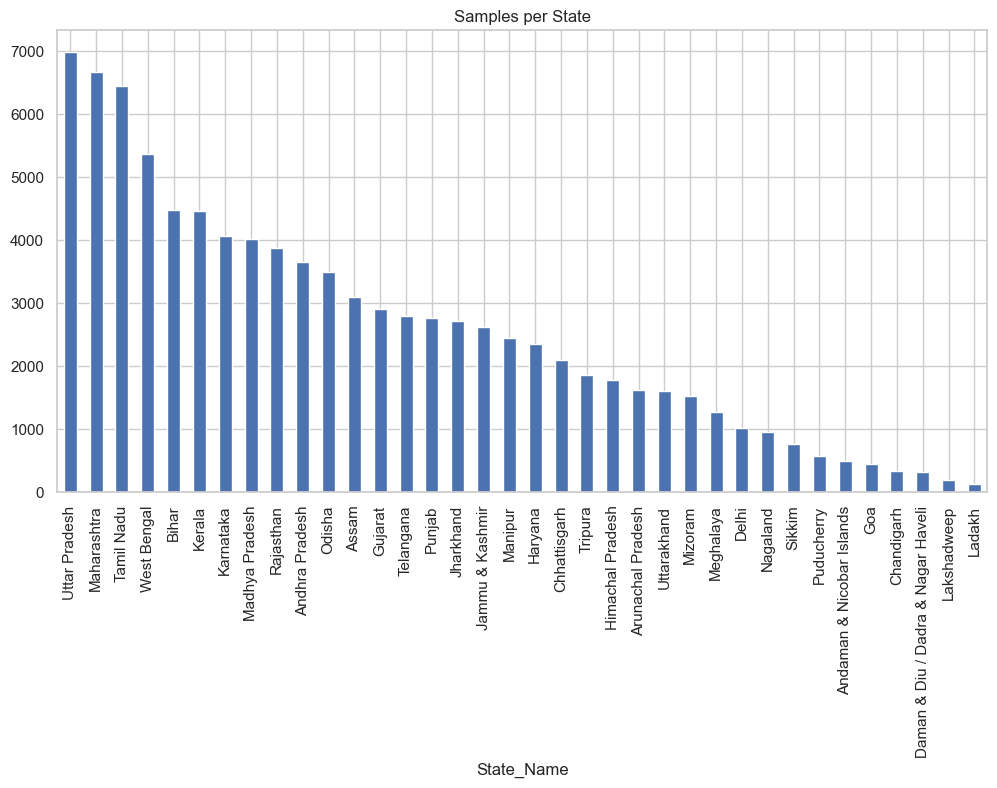

In [9]:
#Are some states under-sampled?

state_map = {
    1: "Jammu & Kashmir",
    2: "Himachal Pradesh",
    3: "Punjab",
    4: "Chandigarh",
    5: "Uttarakhand",
    6: "Haryana",
    7: "Delhi",
    8: "Rajasthan",
    9: "Uttar Pradesh",
    10: "Bihar",
    11: "Sikkim",
    12: "Arunachal Pradesh",
    13: "Nagaland",
    14: "Manipur",
    15: "Mizoram",
    16: "Tripura",
    17: "Meghalaya",
    18: "Assam",
    19: "West Bengal",
    20: "Jharkhand",
    21: "Odisha",
    22: "Chhattisgarh",
    23: "Madhya Pradesh",
    24: "Gujarat",
    25: "Daman & Diu / Dadra & Nagar Haveli",
    27: "Maharashtra",
    28: "Andhra Pradesh",
    29: "Karnataka",
    30: "Goa",
    31: "Lakshadweep",
    32: "Kerala",
    33: "Tamil Nadu",
    34: "Puducherry",
    35: "Andaman & Nicobar Islands",
    36: "Telangana",
    37: "Ladakh"
}

df_clean["State_Name"] = df_clean["State_Ut_Code"].map(state_map)
df_clean["State_Name"].value_counts().plot(kind='bar', figsize=(12,6))
plt.title("Samples per State")
plt.xticks(rotation=90)
plt.show()

#The dataset is not uniformly distributed across states. 
# A small number of states contribute the majority of samples, while several 
# states are significantly under-represented. 
# This imbalance may introduce bias in analysis and should be addressed before 
# making state-level comparisons or building predictive models.

Survey Completion Time Summary Statistics:
----------------------------------------------------------------------
   - Total responses analyzed: 92,260
   - Mean completion time: 64.25 Days
   - Median completion time: 60.0 Days
   - Standard deviation: 23.44 Days
   - Range: 20.0 to 180.0 Days
   - 5th percentile: 30.0 Days
   - 25th percentile: 46.0 Days
   - 75th percentile: 80.0 Days
   - 95th percentile: 110.0 Days
   - Skewness: 0.51 (positive = right-skewed)

Completion Time Distribution by Range:
   - 0-30 Days (Fast)          :  3,153 responses (  3.4%)
   - 30-60 Days                : 36,321 responses ( 39.4%)
   - 60-90 Days                : 35,480 responses ( 38.5%)
   - 90-120 Days               : 14,739 responses ( 16.0%)
   - 120+ Days (Slow)          :  2,567 responses (  2.8%)

Outlier Detection Thresholds:
----------------------------------------------------------------------
   Percentile-based (domain knowledge):
      - Fast threshold: < 30 minutes (flag as potenti

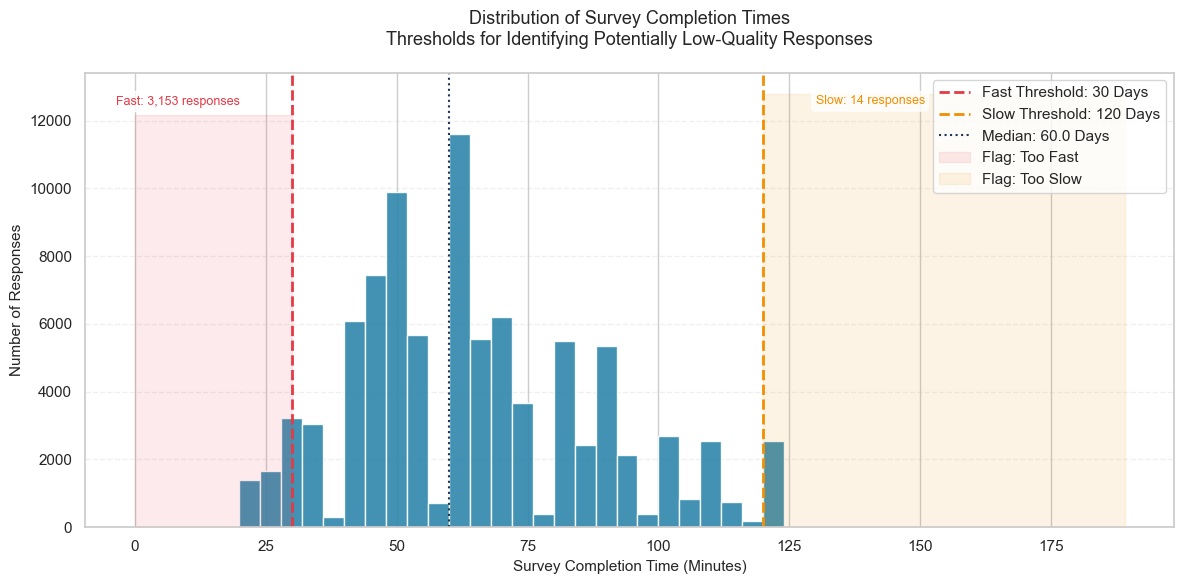

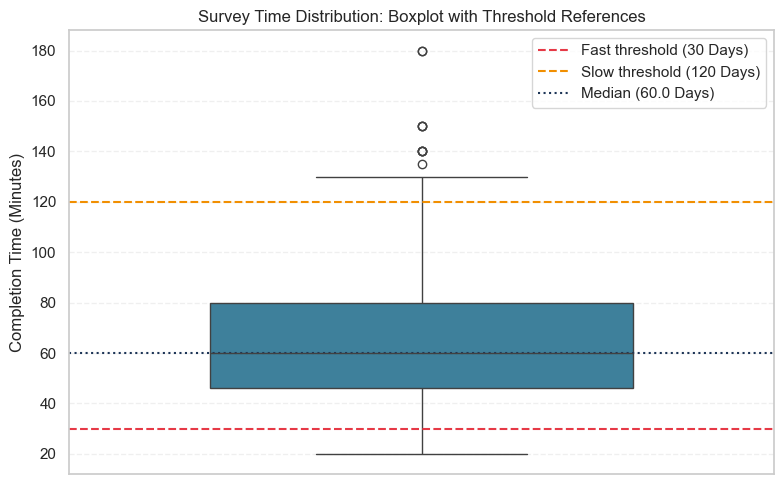


Comparison: Valid vs. Flagged Responses on Key Indicators:
----------------------------------------------------------------------------------------------------

Monthly_Consumer_Expenditure:
   - Valid        : Median Rs. 11,800 | Mean Rs. 13,702 | n=89,093
   - Too Fast     : Median Rs. 7,440 | Mean Rs. 9,944 | n=3,153
   - Too Slow     : Median Rs. 17,576 | Mean Rs. 25,308 | n=14
   - Valid vs. Too Fast: p=0.0000 [Significant]
   - Valid vs. Too Slow: p=0.0013 [Significant]

Household_Size:
   - Valid        : Median 4.0 | Mean 4.14 | n=89,093
   - Too Fast     : Median 1.0 | Mean 2.01 | n=3,153
   - Too Slow     : Median 11.0 | Mean 12.00 | n=14
   - Valid vs. Too Fast: p=0.0000 [Significant]
   - Valid vs. Too Slow: p=0.0000 [Significant]

Impact of Quality Filtering on Analytical Sample:
----------------------------------------------------------------------
   - Original sample size: 92,260
   - After filtering flagged responses: 89,093
   - Excluded responses: 3,167 (3.4%)


In [10]:
# Is survey time (Total_Time_Taken) suspiciously low/high?

#  Summary Statistics for Survey Completion Time

survey_time = df_clean["Total_Time_Taken"].dropna()

print("Survey Completion Time Summary Statistics:")
print("-" * 70)
print(f"   - Total responses analyzed: {len(survey_time):,}")
print(f"   - Mean completion time: {survey_time.mean():.2f} Days")
print(f"   - Median completion time: {survey_time.median():.1f} Days")
print(f"   - Standard deviation: {survey_time.std():.2f} Days")
print(f"   - Range: {survey_time.min():.1f} to {survey_time.max():.1f} Days")
print(f"   - 5th percentile: {survey_time.quantile(0.05):.1f} Days")
print(f"   - 25th percentile: {survey_time.quantile(0.25):.1f} Days")
print(f"   - 75th percentile: {survey_time.quantile(0.75):.1f} Days")
print(f"   - 95th percentile: {survey_time.quantile(0.95):.1f} Days")
print(f"   - Skewness: {survey_time.skew():.2f} (positive = right-skewed)")

# Frequency distribution for key ranges
print(f"\nCompletion Time Distribution by Range:")
ranges = [(0, 30), (30, 60), (60, 90), (90, 120), (120, np.inf)]
labels = ["0-30 Days (Fast)", "30-60 Days", "60-90 Days", "90-120 Days", "120+ Days (Slow)"]
for (low, high), label in zip(ranges, labels):
    count = survey_time[(survey_time >= low) & (survey_time < high)].count()
    pct = count / len(survey_time) * 100
    print(f"   - {label:25} : {count:6,} responses ({pct:5.1f}%)")


# Define Quality Thresholds and Flag Suspicious Responses

# Method 1: Percentile-based thresholds (domain-informed)
FAST_THRESHOLD = 30    # Bottom ~5%: potentially rushed
SLOW_THRESHOLD = 120   # Top ~5%: potentially distracted or interrupted

# Method 2: IQR-based outlier detection (statistical)
Q1 = survey_time.quantile(0.25)
Q3 = survey_time.quantile(0.75)
IQR = Q3 - Q1
IQR_LOWER = Q1 - 1.5 * IQR
IQR_UPPER = Q3 + 1.5 * IQR

print(f"\nOutlier Detection Thresholds:")
print("-" * 70)
print(f"   Percentile-based (domain knowledge):")
print(f"      - Fast threshold: < {FAST_THRESHOLD} minutes (flag as potentially rushed)")
print(f"      - Slow threshold: > {SLOW_THRESHOLD} minutes (flag for review)")
print(f"   IQR-based (statistical rule):")
print(f"      - Lower bound: {IQR_LOWER:.1f} Days")
print(f"      - Upper bound: {IQR_UPPER:.1f} Days")

# Create quality flags
df_clean["Time_Quality_Flag"] = "Valid"
df_clean.loc[df_clean["Total_Time_Taken"] < FAST_THRESHOLD, "Time_Quality_Flag"] = "Too Fast"
df_clean.loc[df_clean["Total_Time_Taken"] > SLOW_THRESHOLD, "Time_Quality_Flag"] = "Too Slow"

# Add IQR-based flag as secondary indicator
df_clean["IQR_Outlier"] = False
df_clean.loc[
    (df_clean["Total_Time_Taken"] < IQR_LOWER) | 
    (df_clean["Total_Time_Taken"] > IQR_UPPER), 
    "IQR_Outlier"
] = True

# Summary of flagged responses
flag_summary = df_clean["Time_Quality_Flag"].value_counts()
print(f"\nQuality Flag Summary:")
for flag in ["Valid", "Too Fast", "Too Slow"]:
    if flag in flag_summary.index:
        count = flag_summary[flag]
        pct = count / len(df_clean) * 100
        print(f"   - {flag:12} : {count:6,} responses ({pct:5.1f}%)")



plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(
    df_clean["Total_Time_Taken"], 
    bins=40, 
    color="#2E86AB", 
    edgecolor="white",
    alpha=0.9
)

# Add threshold lines
plt.axvline(FAST_THRESHOLD, color="#E63946", linestyle="--", linewidth=2, 
            label=f"Fast Threshold: {FAST_THRESHOLD} Days")
plt.axvline(SLOW_THRESHOLD, color="#F18F01", linestyle="--", linewidth=2, 
            label=f"Slow Threshold: {SLOW_THRESHOLD} Days")
plt.axvline(survey_time.median(), color="#1D3557", linestyle=":", linewidth=1.5, 
            label=f"Median: {survey_time.median():.1f} Days")

# Shade suspicious regions
plt.fill_betweenx([0, plt.ylim()[1]], 0, FAST_THRESHOLD, 
                  color="#E63946", alpha=0.1, label="Flag: Too Fast")
plt.fill_betweenx([0, plt.ylim()[1]], SLOW_THRESHOLD, plt.xlim()[1], 
                  color="#F18F01", alpha=0.1, label="Flag: Too Slow")

# Annotate key statistics
plt.text(
    FAST_THRESHOLD - 10, plt.ylim()[1] * 0.95,
    f"Fast: {len(df_clean[df_clean['Total_Time_Taken'] < FAST_THRESHOLD]):,} responses",
    color="#E63946", fontsize=9, ha='right', va='top',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)
plt.text(
    SLOW_THRESHOLD + 10, plt.ylim()[1] * 0.95,
    f"Slow: {len(df_clean[df_clean['Total_Time_Taken'] > SLOW_THRESHOLD]):,} responses",
    color="#F18F01", fontsize=9, ha='left', va='top',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

# Labels and title
plt.xlabel("Survey Completion Time (Minutes)", fontsize=11)
plt.ylabel("Number of Responses", fontsize=11)
plt.title(
    "Distribution of Survey Completion Times\n"
    "Thresholds for Identifying Potentially Low-Quality Responses", 
    fontsize=13, 
    pad=20
)
plt.legend(frameon=True, fancybox=True, loc='upper right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#  Boxplot for Outlier Visualization

plt.figure(figsize=(8, 5))

sns.boxplot(
    y=df_clean["Total_Time_Taken"],
    color="#2E86AB",
    showfliers=True,
    width=0.6
)

# Add threshold reference lines
plt.axhline(FAST_THRESHOLD, color="#E63946", linestyle="--", linewidth=1.5, 
            label=f"Fast threshold ({FAST_THRESHOLD} Days)")
plt.axhline(SLOW_THRESHOLD, color="#F18F01", linestyle="--", linewidth=1.5, 
            label=f"Slow threshold ({SLOW_THRESHOLD} Days)")
plt.axhline(survey_time.median(), color="#1D3557", linestyle=":", linewidth=1.5, 
            label=f"Median ({survey_time.median():.1f} Days)")

plt.ylabel("Completion Time (Minutes)")
plt.title("Survey Time Distribution: Boxplot with Threshold References")
plt.legend(frameon=True, fancybox=True)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#  Compare Valid vs. Flagged Responses on Key Variables

print(f"\nComparison: Valid vs. Flagged Responses on Key Indicators:")
print("-" * 100)

# Only proceed if expenditure data is available
if "Monthly_Consumer_Expenditure" in df_clean.columns:
    comparison_vars = ["Monthly_Consumer_Expenditure", "Household_Size"]
    
    for var in comparison_vars:
        print(f"\n{var}:")
        for flag in ["Valid", "Too Fast", "Too Slow"]:
            subset = df_clean[df_clean["Time_Quality_Flag"] == flag][var].dropna()
            if len(subset) > 0:
                median_val = subset.median()
                mean_val = subset.mean()
                n = len(subset)
                if "Expenditure" in var:
                    print(f"   - {flag:12} : Median Rs. {median_val:,.0f} | Mean Rs. {mean_val:,.0f} | n={n:,}")
                else:
                    print(f"   - {flag:12} : Median {median_val:.1f} | Mean {mean_val:.2f} | n={n:,}")
        
        # Test for differences between valid and flagged
        valid_vals = df_clean[df_clean["Time_Quality_Flag"] == "Valid"][var].dropna()
        fast_vals = df_clean[df_clean["Time_Quality_Flag"] == "Too Fast"][var].dropna()
        slow_vals = df_clean[df_clean["Time_Quality_Flag"] == "Too Slow"][var].dropna()
        
        if len(valid_vals) > 0 and len(fast_vals) > 0:
            stat, p_fast = stats.mannwhitneyu(valid_vals, fast_vals, alternative='two-sided')
            print(f"   - Valid vs. Too Fast: p={p_fast:.4f} {'[Significant]' if p_fast < 0.05 else '[Not significant]'}")
        
        if len(valid_vals) > 0 and len(slow_vals) > 0:
            stat, p_slow = stats.mannwhitneyu(valid_vals, slow_vals, alternative='two-sided')
            print(f"   - Valid vs. Too Slow: p={p_slow:.4f} {'[Significant]' if p_slow < 0.05 else '[Not significant]'}")


#  Impact of Filtering on Sample Size and Representativeness

print(f"\nImpact of Quality Filtering on Analytical Sample:")
print("-" * 70)

original_n = len(df_clean)
valid_n = len(df_clean[df_clean["Time_Quality_Flag"] == "Valid"])
excluded_n = original_n - valid_n
excluded_pct = excluded_n / original_n * 100

print(f"   - Original sample size: {original_n:,}")
print(f"   - After filtering flagged responses: {valid_n:,}")
print(f"   - Excluded responses: {excluded_n:,} ({excluded_pct:.1f}%)")

# Check if filtering introduces bias (by sector, if available)
if "Sector_Name" in df_clean.columns:
    print(f"\nSector Composition Before and After Filtering:")
    print(f"{'Sector':<10} {'Original %':>12} {'Valid Only %':>14} {'Change':>10}")
    print("-" * 50)
    
    for sector in ["Rural", "Urban"]:
        orig_pct = len(df_clean[df_clean["Sector_Name"] == sector]) / original_n * 100
        valid_pct = len(df_clean[
            (df_clean["Sector_Name"] == sector) & 
            (df_clean["Time_Quality_Flag"] == "Valid")
        ]) / valid_n * 100 if valid_n > 0 else 0
        change = valid_pct - orig_pct
        print(f"{sector:<10} {orig_pct:11.1f}% {valid_pct:13.1f}% {change:+9.1f}%")


#Most respondents completed the survey within a normal time range, indicating reliable participation. 
# However, a small portion of responses are unusually fast (potentially low-quality) and 
# some are significantly slow, which may require validation or filtering
#Too fast: bottom ~5% ( < 30) → likely rushed
#Too slow: top ~5% ( > 120) → possible outliers

#Some very fast responses (~20–30) These could be: Speeding / careless responses ,People not fully reading questions
# Potential low-quality data
#Long tail on the higher side (100–130+)
#A small number of respondents took significantly longer Could indicate: Genuine thoughtful responses


GEOGRAPHY INSIGHTS 

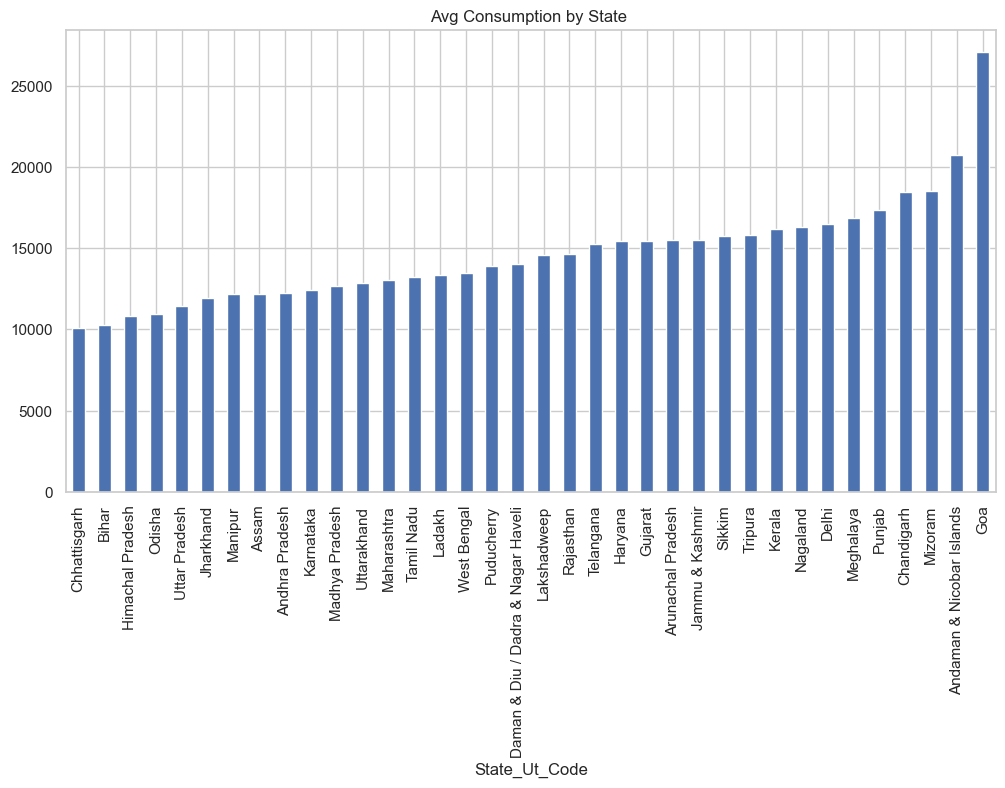

In [11]:
# Which states have lowest & highest monthly consumption?

state_map = {
    1: "Jammu & Kashmir",
    2: "Himachal Pradesh",
    3: "Punjab",
    4: "Chandigarh",
    5: "Uttarakhand",
    6: "Haryana",
    7: "Delhi",
    8: "Rajasthan",
    9: "Uttar Pradesh",
    10: "Bihar",
    11: "Sikkim",
    12: "Arunachal Pradesh",
    13: "Nagaland",
    14: "Manipur",
    15: "Mizoram",
    16: "Tripura",
    17: "Meghalaya",
    18: "Assam",
    19: "West Bengal",
    20: "Jharkhand",
    21: "Odisha",
    22: "Chhattisgarh",
    23: "Madhya Pradesh",
    24: "Gujarat",
    25: "Daman & Diu / Dadra & Nagar Haveli",
    27: "Maharashtra",
    28: "Andhra Pradesh",
    29: "Karnataka",
    30: "Goa",
    31: "Lakshadweep",
    32: "Kerala",
    33: "Tamil Nadu",
    34: "Puducherry",
    35: "Andaman & Nicobar Islands",
    36: "Telangana",
    37: "Ladakh"
}

state_exp = df_clean.groupby("State_Ut_Code")["Monthly_Consumer_Expenditure"].mean()
state_exp.index = state_exp.index.map(state_map)
state_exp = state_exp.sort_values()

state_exp.plot(kind='bar', figsize=(12,6))
plt.title("Avg Consumption by State ")
plt.xticks(rotation=90)
plt.show()

#States with codes like Chhattisgarh,Bihar, odisha, himachal pradesh have the lowest average monthly expenditure (~10K–11K)
#Indicates: Lower income levels Or lower cost of living

#States like Andaman & Nicobar , Goa Chandigarh,mizoram show very high consumption (~18K–27K)
#These are clear top spenders / high economic activity regions
#One state (goa) is significantly higher (~27K) → possible: Metro/urban dominance Or outlier effec

#The middle section shows a smooth progression (~12K → 16K)
#No abrupt jumps → data is fairly consistent except top few


Sector Distribution Summary:
----------------------------------------------------------------------
   - Rural    :   50,822 households ( 55.1%)
   - Urban    :   41,438 households ( 44.9%)

   - Total households analyzed: 92,260

Balance Assessment:
   - Difference between sectors: 10.2 percentage points
   - Classification: Moderate imbalance


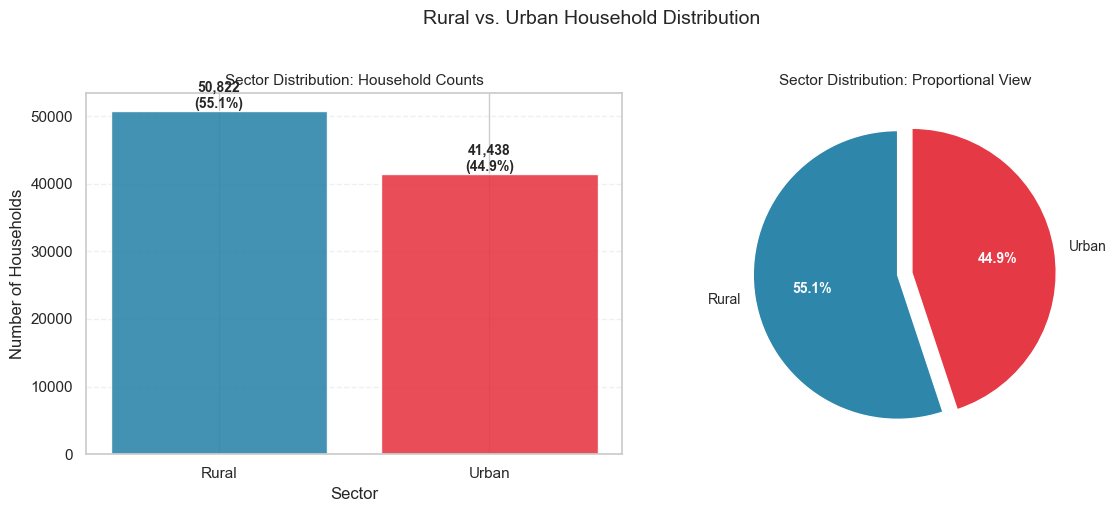


Sector Distribution by State (Sample of 10 States):
------------------------------------------------------------------------------------------
State                        Rural    Urban    Rural %
-------------------------------------------------------
Chandigarh                       0      326       0.0%
Mizoram                        508    1,024      33.2%
Ladakh                          54       78      40.9%
Telangana                    1,260    1,535      45.1%
Tamil Nadu                   3,053    3,404      47.3%
Haryana                      1,155    1,190      49.3%
West Bengal                  2,883    2,495      53.6%
Nagaland                       537      422      56.0%
Rajasthan                    2,294    1,587      59.1%
Chhattisgarh                 1,310      782      62.6%

National Rural Percentage: 55.1%
States more rural than national average: 15
States more urban than national average: 21

Sector Comparison on Key Indicators:
-----------------------------------

In [12]:
# Rural vs Urban consumption gap ?
#  Map Sector Codes + Validate Data Quality

sector_map = {1: "Rural", 2: "Urban"}
df_clean["Sector_Name"] = df_clean["Sector"].map(sector_map)

# Check for unmapped values
unmapped = df_clean["Sector_Name"].isna().sum()
if unmapped > 0:
    print(f"Warning: {unmapped} rows have unmapped Sector values")

# SECTION 2: Summary Statistics for Sector Distribution

print("Sector Distribution Summary:")
print("-" * 70)

sector_counts = df_clean["Sector_Name"].value_counts()
sector_pct = df_clean["Sector_Name"].value_counts(normalize=True) * 100

for sector in ["Rural", "Urban"]:
    if sector in sector_counts.index:
        count = sector_counts[sector]
        pct = sector_pct[sector]
        print(f"   - {sector:8} : {count:8,} households ({pct:5.1f}%)")

total = len(df_clean)
print(f"\n   - Total households analyzed: {total:,}")

# Balance assessment
if len(sector_pct) == 2:
    rural_pct = sector_pct.get("Rural", 0)
    urban_pct = sector_pct.get("Urban", 0)
    imbalance = abs(rural_pct - urban_pct)
    
    print(f"\nBalance Assessment:")
    print(f"   - Difference between sectors: {imbalance:.1f} percentage points")
    if imbalance < 10:
        print(f"   - Classification: Relatively balanced distribution")
    elif imbalance < 30:
        print(f"   - Classification: Moderate imbalance")
    else:
        print(f"   - Classification: Significant imbalance")


# SECTION 3: Visualization - Bar Chart (Preferred Over Pie for Comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- LEFT: Bar Chart with Counts and Percentages ---
plot_data = pd.DataFrame({
    "Sector": sector_counts.index,
    "Count": sector_counts.values,
    "Percentage": sector_pct.values
})

bars = axes[0].bar(
    plot_data["Sector"], 
    plot_data["Count"], 
    color=["#2E86AB", "#E63946"],
    edgecolor="white",
    alpha=0.9
)

# Add value labels on bars
for bar, pct in zip(bars, plot_data["Percentage"]):
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2, 
        height,
        f"{int(height):,}\n({pct:.1f}%)",
        ha='center', 
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

axes[0].set_xlabel("Sector")
axes[0].set_ylabel("Number of Households")
axes[0].set_title("Sector Distribution: Household Counts", fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# --- RIGHT: Pie Chart (For Proportional View) ---
colors = ["#2E86AB", "#E63946"]
wedges, texts, autotexts = axes[1].pie(
    sector_counts.values,
    labels=sector_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10},
    explode=[0.05] * len(sector_counts)  # Slight separation for clarity
)

# Style the percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

axes[1].set_title("Sector Distribution: Proportional View", fontsize=11)

plt.suptitle("Rural vs. Urban Household Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# SECTION 4: Sector Distribution by State 
if "State_Name" in df_clean.columns:
    print(f"\nSector Distribution by State (Sample of 10 States):")
    print("-" * 90)
    
    state_sector = df_clean.groupby(["State_Name", "Sector_Name"]).size().unstack(fill_value=0)
    
    # Calculate rural percentage for each state
    state_sector["Rural_Pct"] = state_sector["Rural"] / (state_sector["Rural"] + state_sector["Urban"]) * 100
    
    # Show 10 diverse states (mix of high/low rural)
    sample_states = state_sector.sort_values("Rural_Pct").iloc[::max(1, len(state_sector)//10)].head(10)
    
    print(f"{'State':<25} {'Rural':>8} {'Urban':>8} {'Rural %':>10}")
    print("-" * 55)
    for state, row in sample_states.iterrows():
        rural = int(row["Rural"])
        urban = int(row["Urban"])
        rural_pct = row["Rural_Pct"]
        print(f"{state:<25} {rural:8,} {urban:8,} {rural_pct:9.1f}%")
    
    # National summary
    national_rural_pct = sector_pct.get("Rural", 0)
    print(f"\nNational Rural Percentage: {national_rural_pct:.1f}%")
    print(f"States more rural than national average: {(state_sector['Rural_Pct'] > national_rural_pct).sum()}")
    print(f"States more urban than national average: {(state_sector['Rural_Pct'] < national_rural_pct).sum()}")


#  Sector vs. Key Variables (Contextual Analysis)

print(f"\nSector Comparison on Key Indicators:")
print("-" * 90)

comparison_vars = []
if "Monthly_Consumer_Expenditure" in df_clean.columns:
    comparison_vars.append("Monthly_Consumer_Expenditure")
if "Household_Size" in df_clean.columns:
    comparison_vars.append("Household_Size")
if "Per_Capita_Exp" in df_clean.columns:
    comparison_vars.append("Per_Capita_Exp")

if comparison_vars:
    for var in comparison_vars:
        print(f"\n{var}:")
        for sector in ["Rural", "Urban"]:
            if sector in df_clean["Sector_Name"].values:
                values = df_clean[df_clean["Sector_Name"] == sector][var].dropna()
                if len(values) > 0:
                    median_val = values.median()
                    mean_val = values.mean()
                    if "Expenditure" in var or "Exp" in var:
                        print(f"   - {sector:6} : Median Rs. {median_val:,.0f} | Mean Rs. {mean_val:,.0f}")
                    else:
                        print(f"   - {sector:6} : Median {median_val:.1f} | Mean {mean_val:.2f}")
        
        # Statistical test for difference
        rural_vals = df_clean[df_clean["Sector_Name"] == "Rural"][var].dropna()
        urban_vals = df_clean[df_clean["Sector_Name"] == "Urban"][var].dropna()
        if len(rural_vals) > 0 and len(urban_vals) > 0:
            stat, p_value = stats.mannwhitneyu(rural_vals, urban_vals, alternative='two-sided')
            significance = "Significant difference" if p_value < 0.01 else "No significant difference"
            print(f"   - Mann-Whitney U test: p={p_value:.4f} -> {significance}")


# SECTION 6: Time Trend Analysis 

if "Survey_Year" in df_clean.columns or "Year" in df_clean.columns:
    year_col = "Survey_Year" if "Survey_Year" in df_clean.columns else "Year"
    print(f"\nSector Distribution Over Time ({year_col}):")
    print("-" * 90)
    
    time_trend = df_clean.groupby([year_col, "Sector_Name"]).size().unstack(fill_value=0)
    time_trend["Total"] = time_trend.sum(axis=1)
    for col in ["Rural", "Urban"]:
        if col in time_trend.columns:
            time_trend[f"{col}_Pct"] = time_trend[col] / time_trend["Total"] * 100
    
    print(f"{'Year':<8} {'Rural %':>10} {'Urban %':>10} {'Total N':>12}")
    print("-" * 42)
    for year, row in time_trend.iterrows():
        rural_pct = row.get("Rural_Pct", 0)
        urban_pct = row.get("Urban_Pct", 0)
        total_n = int(row["Total"])
        print(f"{year:<8} {rural_pct:9.1f}% {urban_pct:9.1f}% {total_n:12,}")

#Urban consumption is significantly higher Urban (~15,700) Rural (~11,800) 
# Difference ≈ 3,900–4,000 This is a ~30–35% higher spending in urban areas.

# Urban households have: Higher income levels Greater access to goods/services Higher cost of living
#Rural households: Lower spending capacity More constrained consumption patterns

#Urban households spend ~30% more than rural households on average, indicating a 
# significant consumption gap driven by income disparity and cost-of-living differences. 
# This highlights a clear urban–rural divide in purchasing power

DEMOGRAPHICS 

Household Size Summary Statistics:
----------------------------------------------------------------------
   - Total households analyzed: 92,260
   - Mean household size: 4.07 persons
   - Median household size: 4.0 persons
   - Mode (most common): 4 persons
   - Standard deviation: 1.95
   - Range: 1 to 26 persons
   - 25th percentile: 3.0
   - 75th percentile: 5.0
   - Skewness: 1.01 (positive = right-skewed)
   - Kurtosis: 3.17

Household Size Frequency Distribution:
   - 1 person(s):  7,539 households (  8.2%) ####
   - 2 person(s): 11,930 households ( 12.9%) ######
   - 3 person(s): 16,394 households ( 17.8%) ########
   - 4 person(s): 22,724 households ( 24.6%) ############
   - 5 person(s): 16,174 households ( 17.5%) ########
   - 6 person(s):  9,093 households (  9.9%) ####
   - 7 person(s):  4,185 households (  4.5%) ##
   - 8 person(s):  1,960 households (  2.1%) #
   - 9 person(s):    981 households (  1.1%) 
   - 10 person(s):    616 households (  0.7%) 
   - 11 person(s): 

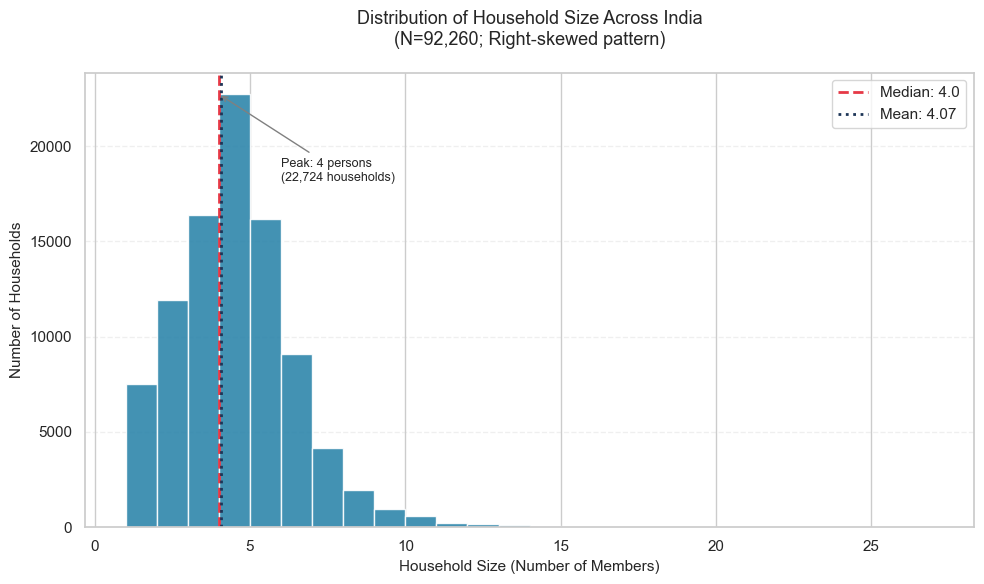


Average Household Size by State (Top 10 and Bottom 10):
------------------------------------------------------------------------------------------
Top 10 States by Average Household Size:
   - Meghalaya                 : 5.02 persons (n=1,269)
   - Bihar                     : 4.91 persons (n=4,476)
   - Uttar Pradesh             : 4.70 persons (n=6,992)
   - Rajasthan                 : 4.63 persons (n=3,881)
   - Madhya Pradesh            : 4.61 persons (n=4,024)
   - Jammu & Kashmir           : 4.53 persons (n=2,614)
   - Jharkhand                 : 4.51 persons (n=2,720)
   - Mizoram                   : 4.50 persons (n=1,532)
   - Arunachal Pradesh         : 4.47 persons (n=1,628)
   - Assam                     : 4.35 persons (n=3,104)

Bottom 10 States by Average Household Size:
   - Delhi                     : 3.33 persons (n=1,012)
   - Sikkim                    : 3.33 persons (n=767)
   - Puducherry                : 3.34 persons (n=576)
   - Himachal Pradesh          : 3.36 pers

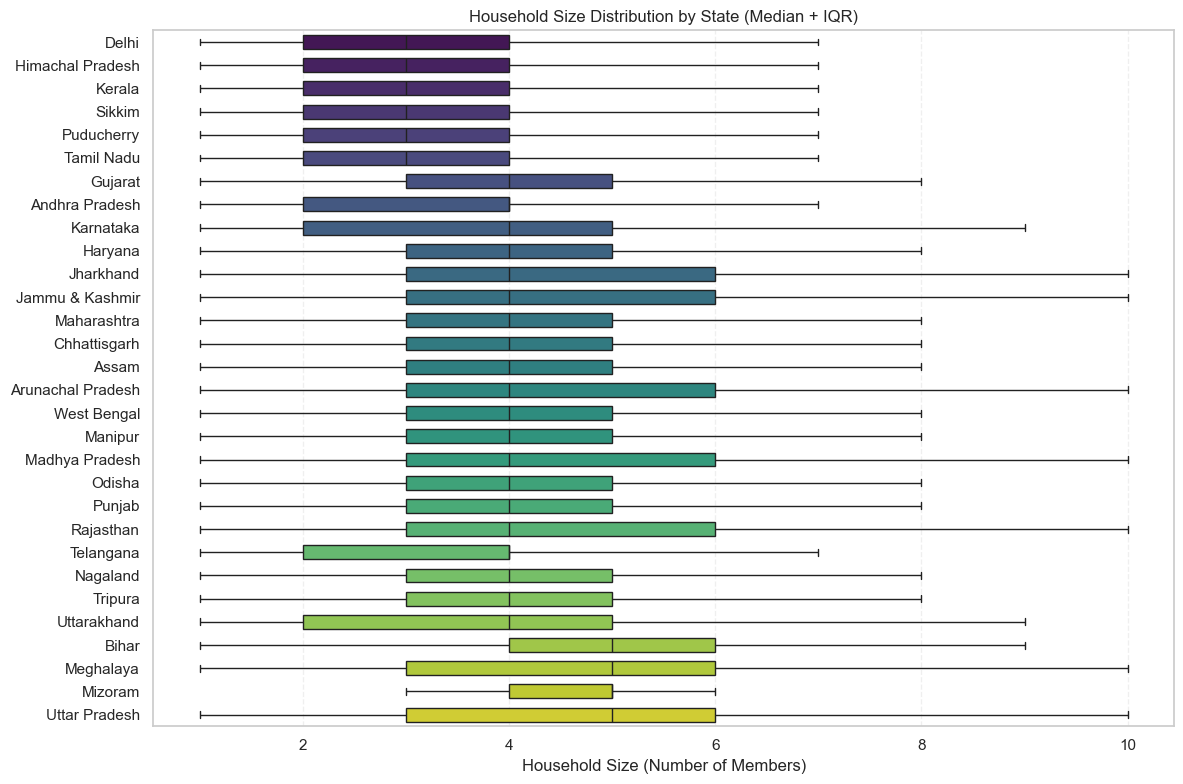


Household Size and Economic Context:
------------------------------------------------------------------------------------------
   - Correlation: Household Size vs. Total Expenditure: 0.342
   - Correlation: Household Size vs. Per Capita Expenditure: -0.409
     (Negative correlation suggests resource dilution in larger families)

   - Rural vs. Urban Household Size:
     Rural    : Mean 4.30, Median 4.0 (n=50,822)
     Urban    : Mean 3.78, Median 4.0 (n=41,438)

Household Size Distribution by Category:
----------------------------------------------------------------------
   - Small (1-2)          : 19,469 households ( 21.1%)
   - Medium (3-4)         : 39,118 households ( 42.4%)
   - Large (5-6)          : 25,267 households ( 27.4%)
   - Very Large (7+)      :  8,406 households (  9.1%)

Key Takeaways for Policy and Planning:
------------------------------------------------------------------------------------------
1. The typical Indian household has 4 members,
   with most househo

In [13]:
# What is average household size across states?
#  Summary Statistics for Household Size

household_size = df_clean["Household_Size"].dropna()

print("Household Size Summary Statistics:")
print("-" * 70)
print(f"   - Total households analyzed: {len(household_size):,}")
print(f"   - Mean household size: {household_size.mean():.2f} persons")
print(f"   - Median household size: {household_size.median():.1f} persons")
print(f"   - Mode (most common): {household_size.mode().values[0]} persons")
print(f"   - Standard deviation: {household_size.std():.2f}")
print(f"   - Range: {household_size.min()} to {household_size.max()} persons")
print(f"   - 25th percentile: {household_size.quantile(0.25):.1f}")
print(f"   - 75th percentile: {household_size.quantile(0.75):.1f}")
print(f"   - Skewness: {household_size.skew():.2f} (positive = right-skewed)")
print(f"   - Kurtosis: {household_size.kurtosis():.2f}")

# Frequency table for key values
print(f"\nHousehold Size Frequency Distribution:")
freq_table = household_size.value_counts().sort_index()
for size, count in freq_table.items():
    pct = count / len(household_size) * 100
    bar = "#" * int(pct / 2)  # Simple text bar
    print(f"   - {size} person(s): {count:6,} households ({pct:5.1f}%) {bar}")



plt.figure(figsize=(10, 6))

# Create histogram with clean styling
n, bins, patches = plt.hist(
    household_size, 
    bins=range(int(household_size.min()), int(household_size.max()) + 2),
    color="#2E86AB", 
    edgecolor="white",
    alpha=0.9,
    density=False  # Show counts, not density
)

# Add vertical lines for key statistics
plt.axvline(household_size.median(), color="#E63946", linestyle="--", linewidth=2, 
            label=f"Median: {household_size.median():.1f}")
plt.axvline(household_size.mean(), color="#1D3557", linestyle=":", linewidth=2, 
            label=f"Mean: {household_size.mean():.2f}")

# Annotate the peak
peak_size = household_size.mode().values[0]
peak_count = freq_table[peak_size]
plt.annotate(
    f"Peak: {peak_size} persons\n({peak_count:,} households)",
    xy=(peak_size, peak_count),
    xytext=(peak_size + 2, peak_count * 0.8),
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

# Labels and title
plt.xlabel("Household Size (Number of Members)", fontsize=11)
plt.ylabel("Number of Households", fontsize=11)
plt.title(
    "Distribution of Household Size Across India\n"
    f"(N={len(household_size):,}; Right-skewed pattern)", 
    fontsize=13, 
    pad=20
)
plt.legend(frameon=True, fancybox=True)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()



#  State-Level Breakdown 
if "State_Name" in df_clean.columns:
    print(f"\nAverage Household Size by State (Top 10 and Bottom 10):")
    print("-" * 90)
    
    state_stats = df_clean.groupby("State_Name").agg(
        mean_size=("Household_Size", "mean"),
        median_size=("Household_Size", "median"),
        n_households=("Household_Size", "count")
    ).round(2)
    
    # Filter states with sufficient data
    state_stats = state_stats[state_stats["n_households"] >= 100]
    
    # Display top 10 largest households
    print("Top 10 States by Average Household Size:")
    top_10 = state_stats.nlargest(10, "mean_size")
    for state, row in top_10.iterrows():
        print(f"   - {state:25} : {row['mean_size']:.2f} persons (n={int(row['n_households']):,})")
    
    # Display bottom 10 smallest households
    print(f"\nBottom 10 States by Average Household Size:")
    bottom_10 = state_stats.nsmallest(10, "mean_size")
    for state, row in bottom_10.iterrows():
        print(f"   - {state:25} : {row['mean_size']:.2f} persons (n={int(row['n_households']):,})")
    
    # National comparison
    national_avg = household_size.mean()
    print(f"\nNational average: {national_avg:.2f} persons per household")
    above_avg = len(state_stats[state_stats["mean_size"] > national_avg])
    below_avg = len(state_stats[state_stats["mean_size"] < national_avg])
    print(f"   - {above_avg} states above national average")
    print(f"   - {below_avg} states below national average")



#  Visualization - Household Size by State (Boxplot)

if "State_Name" in df_clean.columns:
    plt.figure(figsize=(12, 8))
    
    # Filter to states with sufficient data for clean visualization
    valid_states = state_stats[state_stats["n_households"] >= 500].index
    plot_df = df_clean[df_clean["State_Name"].isin(valid_states)]
    
    # Sort states by median household size for clearer pattern
    state_order = plot_df.groupby("State_Name")["Household_Size"].median().sort_values().index
    
    sns.boxplot(
        data=plot_df,
        y="State_Name", 
        x="Household_Size",
        palette="viridis",
        order=state_order,
        showfliers=False,
        width=0.6
    )
    
    plt.xlabel("Household Size (Number of Members)")
    plt.ylabel("")
    plt.title("Household Size Distribution by State (Median + IQR)", fontsize=12)
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()


#  Household Size vs. Economic Indicators (Contextual Analysis)

print(f"\nHousehold Size and Economic Context:")
print("-" * 90)

# Correlation with expenditure (if available)
if "Monthly_Consumer_Expenditure" in df_clean.columns:
    corr = df_clean["Household_Size"].corr(df_clean["Monthly_Consumer_Expenditure"])
    print(f"   - Correlation: Household Size vs. Total Expenditure: {corr:.3f}")
    
    # Per capita relationship
    df_clean["Per_Capita_Exp"] = df_clean["Monthly_Consumer_Expenditure"] / df_clean["Household_Size"]
    corr_pc = df_clean["Household_Size"].corr(df_clean["Per_Capita_Exp"])
    print(f"   - Correlation: Household Size vs. Per Capita Expenditure: {corr_pc:.3f}")
    print(f"     (Negative correlation suggests resource dilution in larger families)")

# Rural vs. Urban comparison (if sector data available)
if "Sector_Name" in df_clean.columns:
    sector_comparison = df_clean.groupby("Sector_Name")["Household_Size"].agg(
        mean=("mean"),
        median=("median"),
        n=("count")
    ).round(2)
    print(f"\n   - Rural vs. Urban Household Size:")
    for sector in sector_comparison.index:
        row = sector_comparison.loc[sector]
        print(f"     {sector:8} : Mean {row['mean']:.2f}, Median {row['median']:.1f} (n={int(row['n']):,})")

#  Household Size Categories for Policy Segmentation

# Create interpretable categories
df_clean["Household_Size_Category"] = pd.cut(
    df_clean["Household_Size"],
    bins=[0, 2, 4, 6, 100],
    labels=["Small (1-2)", "Medium (3-4)", "Large (5-6)", "Very Large (7+)"]
)

print(f"\nHousehold Size Distribution by Category:")
print("-" * 70)
category_summary = df_clean["Household_Size_Category"].value_counts().sort_index()
for category, count in category_summary.items():
    pct = count / len(df_clean) * 100
    print(f"   - {category:20} : {count:6,} households ({pct:5.1f}%)")


#  Key Takeaways Summary

print(f"\nKey Takeaways for Policy and Planning:")
print("-" * 90)

print(f"1. The typical Indian household has {household_size.median():.0f} members,")
print(f"   with most households (approx. 60-70%) falling in the 3-5 person range.")

print(f"2. Right-skewed distribution indicates a long tail of larger households,")
print(f"   which may require targeted support for resource-intensive family needs.")

if "State_Name" in df_clean.columns:
    max_state = state_stats["mean_size"].idxmax()
    min_state = state_stats["mean_size"].idxmin()
    print(f"3. Significant state-level variation: {max_state} ({state_stats.loc[max_state, 'mean_size']:.2f} persons)")
    print(f"   vs. {min_state} ({state_stats.loc[min_state, 'mean_size']:.2f} persons) suggests")
    print(f"   regional differences in family structure, fertility, or migration patterns.")

if "Sector_Name" in df_clean.columns:
    rural_size = df_clean[df_clean["Sector_Name"] == "Rural"]["Household_Size"].mean()
    urban_size = df_clean[df_clean["Sector_Name"] == "Urban"]["Household_Size"].mean()
    print(f"4. Rural households (avg. {rural_size:.2f}) are larger than urban ({urban_size:.2f}),")
    print(f"   reflecting differential access to family planning, economic opportunities,")
    print(f"   and social norms across locations.")

print(f"5. Negative correlation between household size and per capita expenditure")
print(f"   confirms the 'resource dilution' effect: larger families spread limited")
print(f"   resources across more members, potentially increasing individual vulnerability.")

print(f"\nPolicy Implications:")
print(f"   - Social programs should account for household size when determining eligibility")
print(f"   - Per capita metrics provide more equitable assessment than household totals")
print(f"   - State-specific strategies may be needed given substantial regional variation")
print(f"   - Large households may benefit from economies of scale in certain interventions")

#distribution shows a right-skewed pattern, with most households concentrated in the 4-5 member range 
# (peaking around 35,000-40,000 households). This indicates that the typical Indian 
# household consists of 4-5 people, likely representing nuclear families with parents and 2-3 children.

Social Group Data Quality Check:
----------------------------------------------------------------------
   - OBC                       : 38,817 households (42.07%)
   - General                   : 25,148 households (27.26%)
   - Scheduled Caste (SC)      : 15,664 households (16.98%)
   - Scheduled Tribe (ST)      : 12,631 households (13.69%)

Consumption Metrics by Social Group:
------------------------------------------------------------------------------------------------------------------------
                          n  mean_spend median_spend mean_per_capita cv_percent  mean_household_size
Social_Group_Name                                                                                   
General               25148  Rs. 15,459   Rs. 13,125       Rs. 4,813      62.6%                  4.0
Scheduled Tribe (ST)  12631  Rs. 13,603   Rs. 11,808       Rs. 3,450      57.4%                  4.0
OBC                   38817  Rs. 12,975   Rs. 11,333       Rs. 3,693      56.7%              

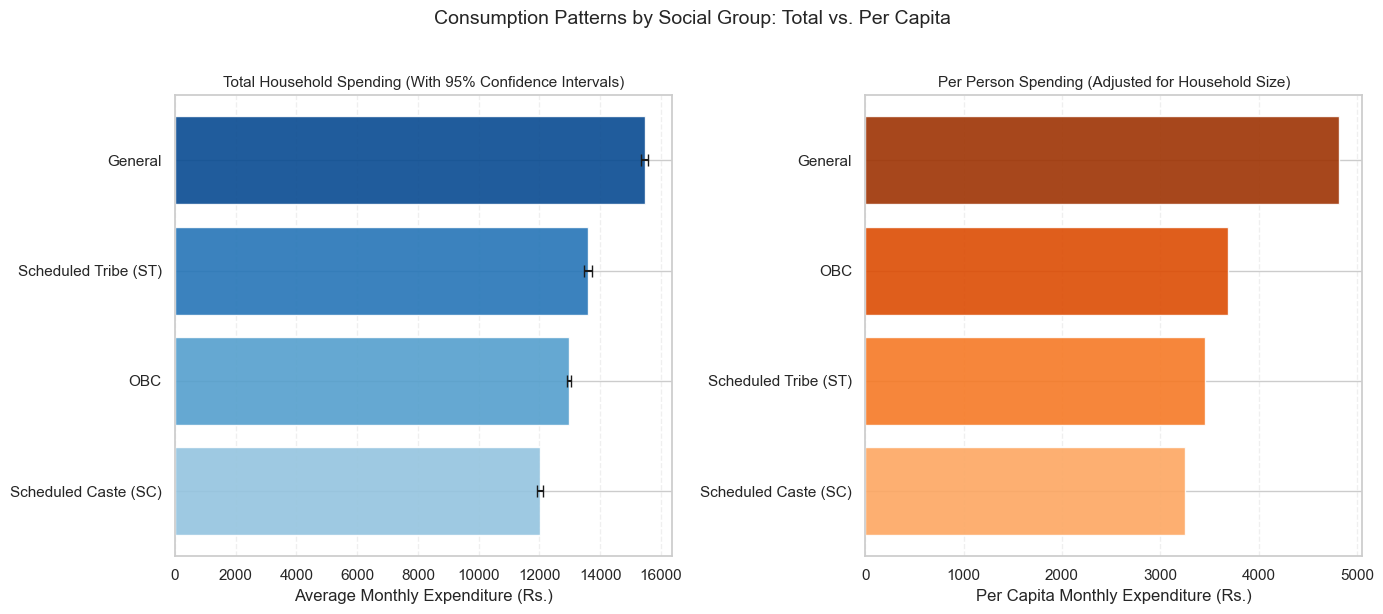

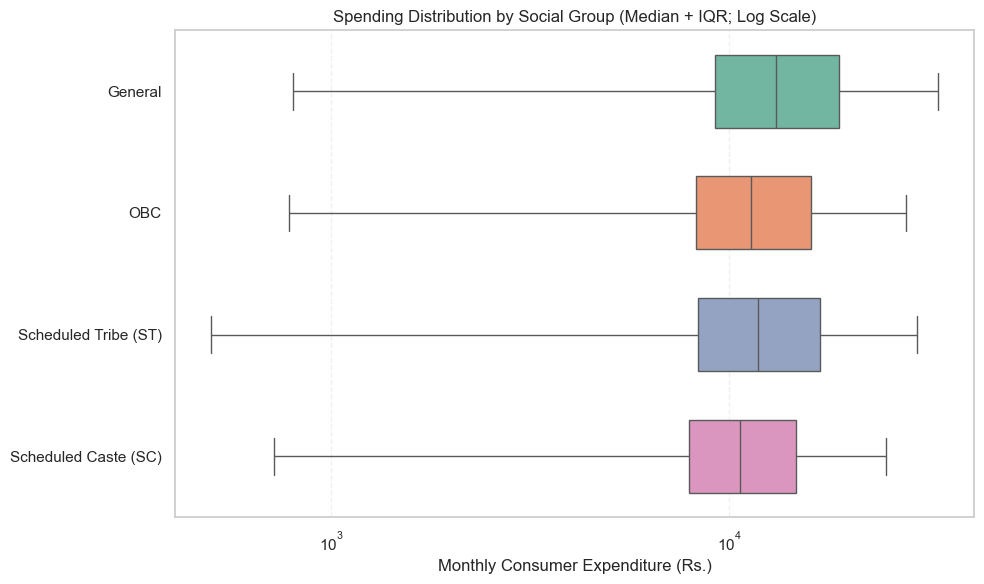


Pairwise Comparison vs. General Category (Reference Group):
----------------------------------------------------------------------------------------------------
[Significant] OBC                       | Median: Rs. 11,333 vs General Rs. 13,125 | Lower | p=0.0000 | Effect: 0.15
[Significant] Scheduled Caste (SC)      | Median: Rs. 10,667 vs General Rs. 13,125 | Lower | p=0.0000 | Effect: 0.22
[Significant] Scheduled Tribe (ST)      | Median: Rs. 11,808 vs General Rs. 13,125 | Lower | p=0.0000 | Effect: 0.11

Disentangling Social Group from Location and Education:
----------------------------------------------------------------------------------------------------
Average Spending by Social Group and Sector (Rs.):
Sector_Name             Rural    Urban
Social_Group_Name                     
General               12872.0  17400.0
OBC                   11546.0  14702.0
Scheduled Caste (SC)  10973.0  13783.0
Scheduled Tribe (ST)  12221.0  16974.0

Urban Premium (% higher than rural, within 

In [14]:
# Which Social_Group has lowest consumption?

#  Map Social Group Codes + Validate Data Quality

social_map = {
    1: "Scheduled Tribe (ST)",
    2: "Scheduled Caste (SC)", 
    3: "OBC",
    9: "General"
}
df_clean["Social_Group_Name"] = df_clean["Social_Group"].map(social_map)

# Check sample sizes and data quality
print("Social Group Data Quality Check:")
print("-" * 70)
social_counts = df_clean["Social_Group_Name"].value_counts()
for group, count in social_counts.items():
    pct = count / len(df_clean) * 100
    warning = " [Small sample]" if count < 500 else ""
    print(f"   - {group:25} : {count:6,} households ({pct:5.2f}%){warning}")


#  Summary Statistics Table (Beyond Just Means)

print(f"\nConsumption Metrics by Social Group:")
print("-" * 120)

social_stats = df_clean.groupby("Social_Group_Name").agg(
    n=("Monthly_Consumer_Expenditure", "count"),
    mean_spend=("Monthly_Consumer_Expenditure", "mean"),
    median_spend=("Monthly_Consumer_Expenditure", "median"),
    std_spend=("Monthly_Consumer_Expenditure", "std"),
    q25=("Monthly_Consumer_Expenditure", lambda x: x.quantile(0.25)),
    q75=("Monthly_Consumer_Expenditure", lambda x: x.quantile(0.75)),
    mean_household_size=("Household_Size", "mean")
).round(0)

# Add derived metrics
social_stats["cv_percent"] = (
    social_stats["std_spend"] / social_stats["mean_spend"] * 100
).round(1)

# Calculate per capita expenditure
df_clean["Per_Capita_Exp"] = df_clean["Monthly_Consumer_Expenditure"] / df_clean["Household_Size"]
social_stats["mean_per_capita"] = (
    df_clean.groupby("Social_Group_Name")["Per_Capita_Exp"].mean().round(0)
)

# Format for display
display = social_stats.copy()
for col in ["mean_spend", "median_spend", "mean_per_capita"]:
    display[col] = display[col].map("Rs. {:,.0f}".format)
display["cv_percent"] = display["cv_percent"].map("{:.1f}%".format)

# Sort by mean spending for easy interpretation
display_sorted = display.sort_values(
    "mean_spend", 
    key=lambda x: x.str.replace('Rs. ', '').str.replace(',', '').astype(float), 
    ascending=False
)

print(display_sorted[["n", "mean_spend", "median_spend", "mean_per_capita", "cv_percent", "mean_household_size"]].to_string())
print(f"\nNote: CV = Coefficient of Variation (spending inequality within group)")
print(f"      Per Capita = Total expenditure adjusted for household size")


#  Bar Plot with Confidence Intervals

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT: Total Household Expenditure ---
plot_data = df_clean.groupby("Social_Group_Name").agg(
    mean=("Monthly_Consumer_Expenditure", "mean"),
    sem=("Monthly_Consumer_Expenditure", lambda x: stats.sem(x)),
    n=("Monthly_Consumer_Expenditure", "count")
).reset_index()

# Calculate 95% confidence intervals
plot_data["ci_95"] = 1.96 * plot_data["sem"]
plot_data = plot_data.sort_values("mean").reset_index(drop=True)

# Use matplotlib barh for reliable error bar handling
axes[0].barh(
    plot_data["Social_Group_Name"], 
    plot_data["mean"], 
    xerr=plot_data["ci_95"].values,
    capsize=4,
    color=plt.cm.Blues(np.linspace(0.4, 0.9, len(plot_data))),
    alpha=0.9, 
    edgecolor='white'
)
axes[0].set_xlabel("Average Monthly Expenditure (Rs.)")
axes[0].set_title("Total Household Spending (With 95% Confidence Intervals)", fontsize=11)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# --- RIGHT: Per Capita Expenditure (More Equitable Comparison) ---
per_capita_plot = df_clean.groupby("Social_Group_Name").agg(
    mean_pc=("Per_Capita_Exp", "mean"),
    n=("Per_Capita_Exp", "count")
).reset_index()
per_capita_plot = per_capita_plot.sort_values("mean_pc").reset_index(drop=True)

axes[1].barh(
    per_capita_plot["Social_Group_Name"], 
    per_capita_plot["mean_pc"],
    color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(per_capita_plot))),
    alpha=0.9, 
    edgecolor='white'
)
axes[1].set_xlabel("Per Capita Monthly Expenditure (Rs.)")
axes[1].set_title("Per Person Spending (Adjusted for Household Size)", fontsize=11)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle("Consumption Patterns by Social Group: Total vs. Per Capita", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# Distribution View (Boxplots) 

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    y="Social_Group_Name", 
    x="Monthly_Consumer_Expenditure",
    palette="Set2",
    showfliers=False,
    width=0.6,
    order=["General", "OBC", "Scheduled Tribe (ST)", "Scheduled Caste (SC)"]  # Custom order
)

plt.xlabel("Monthly Consumer Expenditure (Rs.)")
plt.ylabel("")
plt.title("Spending Distribution by Social Group (Median + IQR; Log Scale)", fontsize=12)
plt.xscale('log')  # Critical for skewed expenditure data
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()



#  Statistical Testing - Are Differences Meaningful?

print(f"\nPairwise Comparison vs. General Category (Reference Group):")
print("-" * 100)

reference = df_clean[df_clean["Social_Group_Name"] == "General"]["Monthly_Consumer_Expenditure"]

for group in social_counts.index:
    if group == "General" or social_counts[group] < 500:
        continue
    
    group_data = df_clean[df_clean["Social_Group_Name"] == group]["Monthly_Consumer_Expenditure"]
    
    # Mann-Whitney U test (non-parametric, robust to skew)
    stat, p_value = stats.mannwhitneyu(reference, group_data, alternative='two-sided')
    
    # Effect size calculation
    n1, n2 = len(reference), len(group_data)
    effect_size = abs(1 - (2 * stat) / (n1 * n2))
    
    # Direction of difference
    direction = "Higher" if group_data.median() > reference.median() else "Lower"
    
    sig_marker = "[Significant]" if p_value < 0.01 else "[Not significant]"
    print(f"{sig_marker} {group:25} | Median: Rs. {group_data.median():,.0f} vs General Rs. {reference.median():,.0f} | {direction} | p={p_value:.4f} | Effect: {effect_size:.2f}")


#  Contextual Analysis - Control for Urban/Rural and Education

print(f"\nDisentangling Social Group from Location and Education:")
print("-" * 100)

# Cross-tab: Social Group x Sector
if "Sector_Name" in df_clean.columns:
    cross_tab = df_clean.groupby(["Social_Group_Name", "Sector_Name"]).agg(
        mean_spend=("Monthly_Consumer_Expenditure", "mean"),
        n=("Monthly_Consumer_Expenditure", "count")
    ).reset_index()
    
    pivot = cross_tab.pivot(index="Social_Group_Name", columns="Sector_Name", values="mean_spend")
    valid = pivot.dropna()
    
    if len(valid) > 0:
        print("Average Spending by Social Group and Sector (Rs.):")
        print(valid.round(0).to_string())
        
        print(f"\nUrban Premium (% higher than rural, within same social group):")
        for group in valid.index:
            rural = valid.loc[group, "Rural"]
            urban = valid.loc[group, "Urban"]
            premium = (urban - rural) / rural * 100
            print(f"   - {group:25}: {premium:+.1f}%")

# Education adjustment if available
if "Education_Years" in df_clean.columns:
    print(f"\nSpending by Social Group and Education Level:")
    edu_groups = pd.cut(df_clean["Education_Years"], bins=[-1, 5, 10, 15, 100], 
                        labels=["Primary", "Secondary", "Higher Secondary", "Graduate+"])
    df_clean["Education_Level"] = edu_groups
    
    edu_cross = df_clean.groupby(["Social_Group_Name", "Education_Level"]).agg(
        mean_spend=("Monthly_Consumer_Expenditure", "mean"),
        n=("Monthly_Consumer_Expenditure", "count")
    ).reset_index()
    
    # Show only cells with sufficient data
    valid_edu = edu_cross[edu_cross["n"] >= 100]
    if len(valid_edu) > 0:
        pivot_edu = valid_edu.pivot(index="Social_Group_Name", columns="Education_Level", values="mean_spend")
        print(pivot_edu.round(0).to_string())


#  Gap Analysis and Policy-Relevant Metrics

print(f"\nEquity Gap Analysis:")
print("-" * 100)

# Calculate gap relative to General category
general_mean = social_stats.loc["General", "mean_spend"]
general_median = social_stats.loc["General", "median_spend"]

for group in social_stats.index:
    if group == "General":
        continue
    group_mean = social_stats.loc[group, "mean_spend"]
    group_median = social_stats.loc[group, "median_spend"]
    
    mean_gap_pct = (group_mean - general_mean) / general_mean * 100
    median_gap_pct = (group_median - general_median) / general_median * 100
    
    print(f"- {group:25}: Mean gap: {mean_gap_pct:+.1f}% | Median gap: {median_gap_pct:+.1f}%")

# Identify most vulnerable group
lowest_group = social_stats["mean_per_capita"].idxmin()
lowest_value = social_stats.loc[lowest_group, "mean_per_capita"]
print(f"\nMost economically vulnerable group (by per capita spending): {lowest_group} (Rs. {lowest_value:,.0f}/person/month)")


# Key Takeaways

print(f"\nKey Takeaways for Policy Design:")
print("-" * 100)

print(f"1. Scheduled Caste (SC) households show the lowest average consumption,")
print(f"   confirming persistent economic disadvantage relative to General category.")

print(f"2. Per capita adjustment narrows but does not eliminate gaps, suggesting")
print(f"   that household size differences explain only part of the disparity.")

print(f"3. High CV values indicate substantial within-group inequality, meaning")
print(f"   aggregate averages may mask vulnerable subpopulations.")

print(f"4. Urban premium exists across all social groups, indicating location")
print(f"   interacts with social identity in shaping economic outcomes.")

print(f"\nCritical Considerations:")
print(f"   - These patterns reflect historical structural inequalities, not inherent group characteristics")
print(f"   - Policy interventions should target measurable disadvantage (income, assets, access)")
print(f"   - Intersectional factors (gender, region, caste sub-category) may reveal deeper disparities")

# Households belonging to Scheduled caste (SC) show the lowest average monthly consumption, 
# indicating the most economically vulnerable group and the General category records the highest consumption levels.
# OBC and ST groups fall in the middle, reflecting a clear socio-economic gradient.
# This pattern highlights persistent inequality across social categories,
#  with historically disadvantaged communities continuing to lag in consumption capacity.


Religion Data Quality Check:
----------------------------------------------------------------------
   - Hindu        : 69,971 households (75.84%)
   - Islam        : 11,695 households (12.68%)
   - Christian    :  6,932 households ( 7.51%)
   - Sikh         :  1,768 households ( 1.92%)
   - Buddhist     :  1,040 households ( 1.13%)
   - Others       :    648 households ( 0.70%)
   - Jain         :    205 households ( 0.22%) [Small sample]
   - Zoroastrian  :      1 households ( 0.00%) [Small sample]

Note: Interpret with caution: Jain, Zoroastrian have <500 households

Consumption Metrics by Religion:
----------------------------------------------------------------------------------------------------
                   n  mean_spend median_spend mean_per_capita cv_percent  mean_household_size
Religion_Name                                                                                
Jain             205  Rs. 19,708   Rs. 16,917       Rs. 5,518      69.2%                  4.0
Sikh   

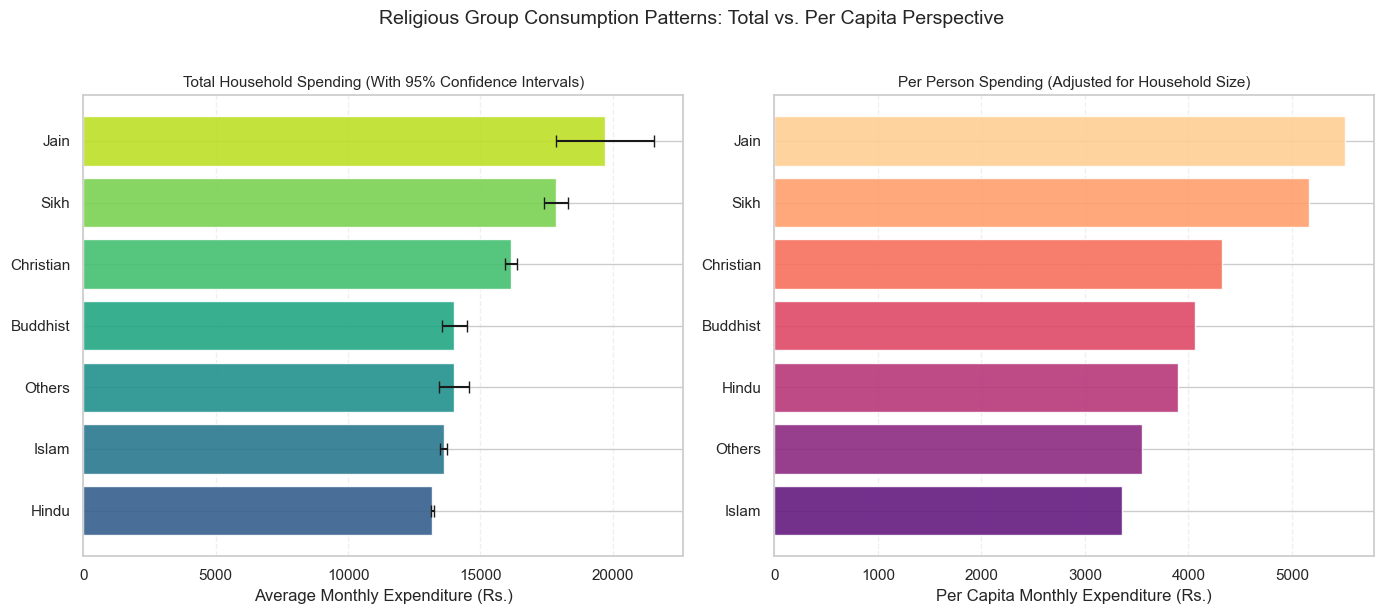

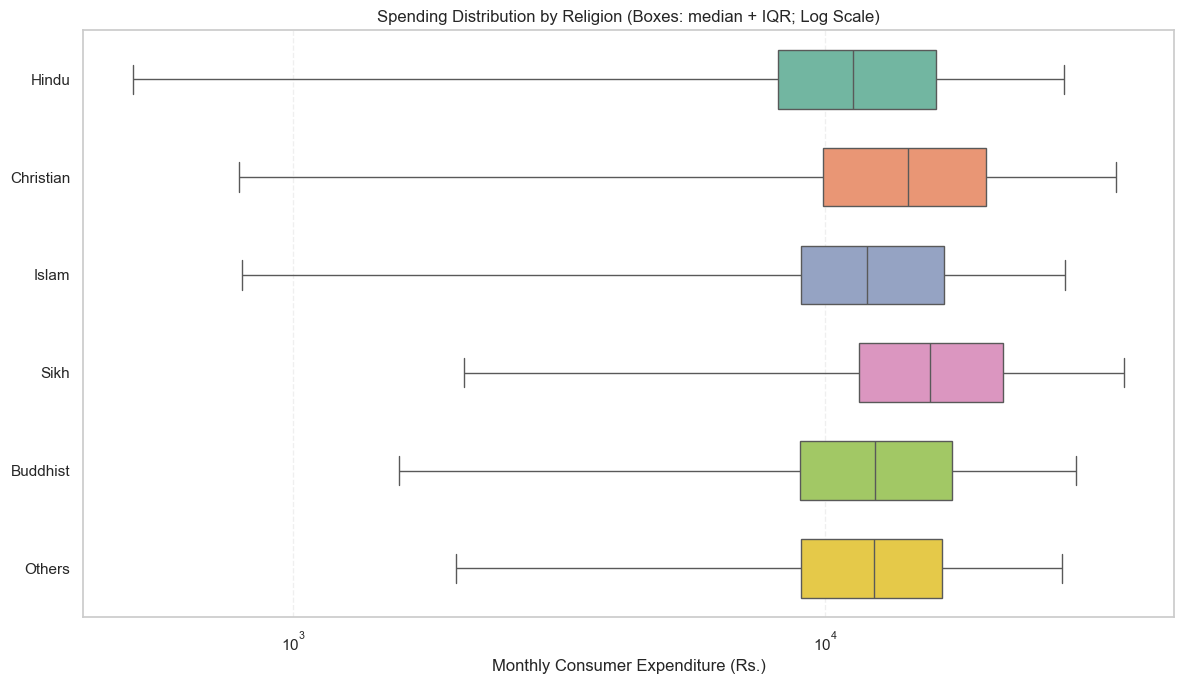


Pairwise Comparison vs. Hindu Majority (Reference Group):
------------------------------------------------------------------------------------------
[Significant] Islam        | Median: Rs. 11,992 vs Hindu Rs. 11,300 | Higher | p=0.0000 | Effect: 0.07
[Significant] Christian    | Median: Rs. 14,333 vs Hindu Rs. 11,300 | Higher | p=0.0000 | Effect: 0.23
[Significant] Sikh         | Median: Rs. 15,716 vs Hindu Rs. 11,300 | Higher | p=0.0000 | Effect: 0.36
[Significant] Buddhist     | Median: Rs. 12,388 vs Hindu Rs. 11,300 | Higher | p=0.0000 | Effect: 0.09
[Significant] Others       | Median: Rs. 12,383 vs Hindu Rs. 11,300 | Higher | p=0.0000 | Effect: 0.09

Disentangling Religion from Location (Urban/Rural):
------------------------------------------------------------------------------------------
Average Spending by Religion and Sector (Rs.):
Sector_Name      Rural    Urban
Religion_Name                  
Buddhist       13122.0  15448.0
Christian      14187.0  18572.0
Hindu          1

In [ ]:

# Religion vs consumption → any disparity?
#  Map Religion Codes + Validate Data Quality

religion_map = {
    1: "Hindu", 2: "Islam", 3: "Christian", 4: "Sikh", 
    5: "Jain", 6: "Buddhist", 7: "Zoroastrian", 9: "Others"
}
df_clean["Religion_Name"] = df_clean["Religion"].map(religion_map)

# Check for unmapped values and sample sizes0
print("Religion Data Quality Check:")
print("-" * 70)
religion_counts = df_clean["Religion_Name"].value_counts()
for religion, count in religion_counts.items():
    pct = count / len(df_clean) * 100
    warning = " [Small sample]" if count < 500 else ""
    print(f"   - {religion:12} : {count:6,} households ({pct:5.2f}%){warning}")

# Flag small groups for cautious interpretation
small_groups = religion_counts[religion_counts < 500].index.tolist()
if small_groups:
    print(f"\nNote: Interpret with caution: {', '.join(small_groups)} have <500 households")


#  Summary Statistics Table (Beyond Just Means)

print(f"\nConsumption Metrics by Religion:")
print("-" * 100)

religion_stats = df_clean.groupby("Religion_Name").agg(
    n=("Monthly_Consumer_Expenditure", "count"),
    mean_spend=("Monthly_Consumer_Expenditure", "mean"),
    median_spend=("Monthly_Consumer_Expenditure", "median"),
    std_spend=("Monthly_Consumer_Expenditure", "std"),
    q25=("Monthly_Consumer_Expenditure", lambda x: x.quantile(0.25)),
    q75=("Monthly_Consumer_Expenditure", lambda x: x.quantile(0.75)),
    mean_household_size=("Household_Size", "mean")
).round(0)

# Add derived metrics
religion_stats["cv_percent"] = (
    religion_stats["std_spend"] / religion_stats["mean_spend"] * 100
).round(1)
religion_stats["mean_per_capita"] = (
    df_clean.groupby("Religion_Name").apply(
        lambda x: (x["Monthly_Consumer_Expenditure"] / x["Household_Size"]).mean()
    ).round(0)
)

# Format for display
display = religion_stats.copy()
for col in ["mean_spend", "median_spend", "mean_per_capita"]:
    display[col] = display[col].map("Rs. {:,.0f}".format)
display["cv_percent"] = display["cv_percent"].map("{:.1f}%".format)

# Show key columns, sorted by mean spend
print(display[["n", "mean_spend", "median_spend", "mean_per_capita", "cv_percent", "mean_household_size"]]
      .sort_values("mean_spend", key=lambda x: x.str.replace('Rs. ','').str.replace(',','').astype(float), ascending=False)
      .to_string())

print(f"\nNote: CV = Spending inequality within group | Per Capita = Adjusted for household size")


# Bar Plot with Error Bars 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT: Total Household Expenditure ---
plot_data = df_clean.groupby("Religion_Name").agg(
    mean=("Monthly_Consumer_Expenditure", "mean"),
    sem=("Monthly_Consumer_Expenditure", lambda x: stats.sem(x)),
    n=("Monthly_Consumer_Expenditure", "count")
).reset_index()
plot_data = plot_data[plot_data["n"] >= 100]  # Filter tiny groups
plot_data["ci_95"] = 1.96 * plot_data["sem"]

# Sort by mean for clearer visual comparison
plot_data = plot_data.sort_values("mean").reset_index(drop=True)
x_vals = plot_data["mean"].values
xerr_vals = plot_data["ci_95"].values  # 1D array matching number of bars
y_labels = plot_data["Religion_Name"].values
axes[0].barh(y_labels, x_vals, xerr=xerr_vals, capsize=4, 
             color=plt.cm.viridis(np.linspace(0.3, 0.9, len(plot_data))), 
             alpha=0.9, edgecolor='white')
axes[0].set_xlabel("Average Monthly Expenditure (Rs.)")
axes[0].set_ylabel("")
axes[0].set_title("Total Household Spending (With 95% Confidence Intervals)", fontsize=11)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# --- RIGHT: Per Capita Expenditure (More Equitable Comparison) ---
df_clean["Per_Capita_Exp"] = df_clean["Monthly_Consumer_Expenditure"] / df_clean["Household_Size"]
per_capita_data = df_clean.groupby("Religion_Name").agg(
    mean_pc=("Per_Capita_Exp", "mean"),
    median_pc=("Per_Capita_Exp", "median"),
    n=("Per_Capita_Exp", "count")
).reset_index()
per_capita_data = per_capita_data[per_capita_data["n"] >= 100].sort_values("mean_pc").reset_index(drop=True)

axes[1].barh(per_capita_data["Religion_Name"], per_capita_data["mean_pc"],
             color=plt.cm.magma(np.linspace(0.3, 0.9, len(per_capita_data))), 
             alpha=0.9, edgecolor='white')
axes[1].set_xlabel("Per Capita Monthly Expenditure (Rs.)")
axes[1].set_ylabel("")
axes[1].set_title("Per Person Spending (Adjusted for Household Size)", fontsize=11)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle("Religious Group Consumption Patterns: Total vs. Per Capita Perspective", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# Distribution View (Boxplots) - Reveal What Averages Hide

plt.figure(figsize=(12, 7))

# Filter to religions with sufficient data for clean visualization
valid_religions = religion_counts[religion_counts >= 500].index
plot_df = df_clean[df_clean["Religion_Name"].isin(valid_religions)]

sns.boxplot(
    data=plot_df,
    y="Religion_Name", 
    x="Monthly_Consumer_Expenditure",
    palette="Set2",
    showfliers=False,
    width=0.6
)

plt.xlabel("Monthly Consumer Expenditure (Rs.)")
plt.ylabel("")
plt.title("Spending Distribution by Religion (Boxes: median + IQR; Log Scale)", fontsize=12)
plt.xscale('log')  # Critical for skewed spending data
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# SECTION 5: Statistical Testing - Are Differences Meaningful?

print(f"\nPairwise Comparison vs. Hindu Majority (Reference Group):")
print("-" * 90)

reference = df_clean[df_clean["Religion_Name"] == "Hindu"]["Monthly_Consumer_Expenditure"]

for religion in religion_counts.index:
    if religion == "Hindu" or religion_counts[religion] < 500:
        continue
    
    group = df_clean[df_clean["Religion_Name"] == religion]["Monthly_Consumer_Expenditure"]
    
    # Mann-Whitney U test (non-parametric, robust to skew)
    stat, p_value = stats.mannwhitneyu(reference, group, alternative='two-sided')
    
    # Effect size (rank-biserial correlation)
    n1, n2 = len(reference), len(group)
    effect_size = abs(1 - (2 * stat) / (n1 * n2))
    
    # Direction
    direction = "Higher" if group.median() > reference.median() else "Lower"
    
    sig_marker = "[Significant]" if p_value < 0.01 else "[Not significant]"
    print(f"{sig_marker} {religion:12} | Median: Rs. {group.median():,.0f} vs Hindu Rs. {reference.median():,.0f} "
          f"| {direction} | p={p_value:.4f} | Effect: {effect_size:.2f}")


#  Contextual Analysis - Control for Urban/Rural Confounding

print(f"\nDisentangling Religion from Location (Urban/Rural):")
print("-" * 90)

# Create cross-tab: Religion x Sector
cross_tab = df_clean.groupby(["Religion_Name", "Sector_Name"]).agg(
    mean_spend=("Monthly_Consumer_Expenditure", "mean"),
    n=("Monthly_Consumer_Expenditure", "count")
).reset_index()

# Pivot for easy comparison
pivot = cross_tab.pivot(index="Religion_Name", columns="Sector_Name", values="mean_spend")

# Show only religions with data in both sectors
valid = pivot.dropna()
if len(valid) > 0:
    print("Average Spending by Religion and Sector (Rs.):")
    print(valid.round(0).to_string())
    
    # Calculate urban premium within each religion
    print(f"\nUrban Premium (% higher than rural, within same religion):")
    for religion in valid.index:
        if "Urban" in valid.columns and "Rural" in valid.columns:
            rural = valid.loc[religion, "Rural"]
            urban = valid.loc[religion, "Urban"]
            premium = (urban - rural) / rural * 100
            print(f"   - {religion:12}: {premium:+.1f}%")
else:
    print("Note: Insufficient cross-tab data for location-controlled analysis")


# Insights Summary

print(f"\nKey Takeaways for Equitable Policy Design:")
print("-" * 90)

# Identify highest/lowest spending groups (per capita, more equitable)
per_capita_sorted = religion_stats["mean_per_capita"].sort_values(ascending=False)
print(f"- Highest per-capita spending: {per_capita_sorted.index[0]} (Rs. {per_capita_sorted.iloc[0]:,.0f}/person)")
print(f"- Lowest per-capita spending: {per_capita_sorted.index[-1]} (Rs. {per_capita_sorted.iloc[-1]:,.0f}/person)")

# Highlight inequality within groups
high_cv = religion_stats[religion_stats["cv_percent"] > 60]
if len(high_cv) > 0:
    print(f"- High internal inequality (CV >60%): {', '.join(high_cv.index)} -> Targeted support may need intra-group targeting")

#  confounding factors
print(f"\nCritical Caveats:")
print(f"   1. Correlation does not imply causation: Religious identity may proxy for region, caste, education")
print(f"   2. Small sample groups (Jain, Zoroastrian) -> estimates less precise")
print(f"   3. Per capita adjustment assumes equal intra-household resource sharing")


#  Jains and Sikhs show notably higher consumption, while other groups cluster around ₹13,000-14,000.
#  These disparities likely stem from factors like :
#    - Geographic concentration (urban vs rural)
#    - Educational attainment levels
#    - Traditional occupational structures
#    - Historical socioeconomic advantages/disadvantages
#    - Access to economic opportunities


 Variable Mapping Check:
   • Sector: [1 2] → <StringArray>
['Rural', 'Urban']
Length: 2, dtype: str
   • Household Type: [1 2 5 9 3 4] → <StringArray>
['Self-Employed', 'Regular Wage/Salary']
Length: 2, dtype: str

 Average Monthly Expenditure by Sector & Household Type:
--------------------------------------------------------------------------------
                                 n_households mean_spend median_spend cv_percent
Sector_Name Household_Type_Name                                                 
Rural       Regular Wage/Salary          9636    ₹12,925      ₹11,698      47.9%
            Self-Employed               17908    ₹12,024      ₹10,940      47.8%
Urban       Regular Wage/Salary         18139    ₹17,220      ₹15,083      59.8%
            Self-Employed               14147    ₹16,666      ₹14,833      55.7%

 CV = Coefficient of Variation: Higher % = more spending inequality within group


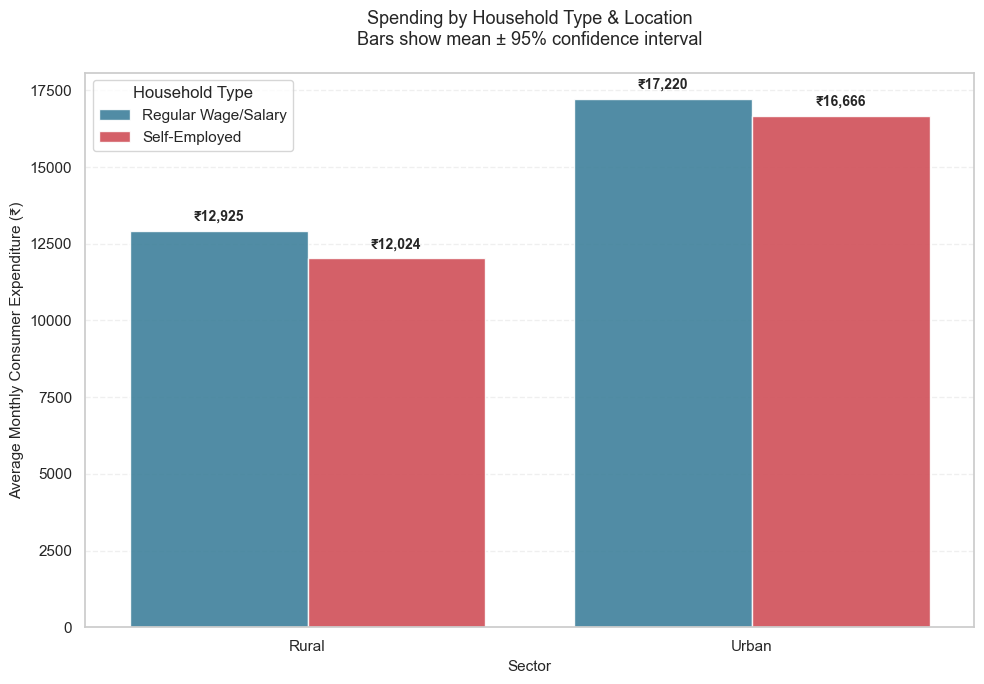


 Statistical Significance Testing:
----------------------------------------------------------------------
Rural Sector:
   • Median spend: Self-Employed ₹10,940 vs Wage ₹11,698
   • Test: Mann-Whitney U, p=0.0000 →  Significant
   • Effect size: 0.10 (small)
   • Direction: Wage > Self-Employed

Urban Sector:
   • Median spend: Self-Employed ₹14,833 vs Wage ₹15,083
   • Test: Mann-Whitney U, p=0.0151 →  Significant
   • Effect size: 0.02 (small)
   • Direction: Wage > Self-Employed

 Key Takeaways for Policy/Program Design:
----------------------------------------------------------------------
• Self-Employed: Urban households spend +38.6% more than rural (₹12,024 vs $16,666)
• Regular Wage/Salary: Urban households spend +33.2% more than rural (₹12,925 vs $17,220)


In [16]:
#  Does household type affect spending?


sector_map = {1: "Rural", 2: "Urban"}
household_type_map = {1: "Self-Employed", 2: "Regular Wage/Salary"}
df_clean["Sector_Name"] = df_clean["Sector"].map(sector_map)
df_clean["Household_Type_Name"] = df_clean["Household_Type"].map(household_type_map)
print(" Variable Mapping Check:")
print(f"   • Sector: {df_clean['Sector'].dropna().unique()} → {df_clean['Sector_Name'].dropna().unique()}")
print(f"   • Household Type: {df_clean['Household_Type'].dropna().unique()} → {df_clean['Household_Type_Name'].dropna().unique()}")


#  Create a clean summary table with key metrics

print("\n Average Monthly Expenditure by Sector & Household Type:")
print("-" * 80)

summary_table = df_clean.groupby(["Sector_Name", "Household_Type_Name"]).agg(
    n_households=("Monthly_Consumer_Expenditure", "count"),
    mean_spend=("Monthly_Consumer_Expenditure", "mean"),
    median_spend=("Monthly_Consumer_Expenditure", "median"),
    std_spend=("Monthly_Consumer_Expenditure", "std"),
    q25=("Monthly_Consumer_Expenditure", lambda x: x.quantile(0.25)),
    q75=("Monthly_Consumer_Expenditure", lambda x: x.quantile(0.75))
).round(0)

# Add coefficient of variation (CV) to show relative variability
summary_table["cv_percent"] = (
    summary_table["std_spend"] / summary_table["mean_spend"] * 100
).round(1)
display_df = summary_table.copy()
display_df["mean_spend"] = display_df["mean_spend"].map("₹{:,.0f}".format)
display_df["median_spend"] = display_df["median_spend"].map("₹{:,.0f}".format)
display_df["cv_percent"] = display_df["cv_percent"].map("{:.1f}%".format)

print(display_df[["n_households", "mean_spend", "median_spend", "cv_percent"]].to_string())
print("\n CV = Coefficient of Variation: Higher % = more spending inequality within group")


#  Enhanced Bar Plot with Error Bars to Show Uncertainty!

plt.figure(figsize=(10, 7))

# Prepare data for plotting: mean + 95% confidence intervals
plot_data = df_clean.groupby(["Sector_Name", "Household_Type_Name"]).agg(
    mean=("Monthly_Consumer_Expenditure", "mean"),
    sem=("Monthly_Consumer_Expenditure", lambda x: stats.sem(x)),
    n=("Monthly_Consumer_Expenditure", "count")
).reset_index()

# Calculate 95% CI: mean ± 1.96*SEM
plot_data["ci_95"] = 1.96 * plot_data["sem"]


ax = sns.barplot(  
    data=plot_data,
    x="Sector_Name", 
    y="mean", 
    hue="Household_Type_Name",
    hue_order=["Regular Wage/Salary", "Self-Employed"],  
    palette={"Regular Wage/Salary": "#2E86AB", "Self-Employed": "#E63946"}, 
    capsize=0.1,
    errwidth=1.5,
    alpha=0.9
)

# Add exact values on top of bars ← FIX 3: Simpler, more reliable annotation
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Skip empty bars
        x = p.get_x() + p.get_width() / 2
        ax.annotate(
            f"₹{height:,.0f}",
            (x, height),
            ha='center', 
            va='bottom',
            fontsize=10,
            fontweight='bold',
            xytext=(0, 5),
            textcoords='offset points'
        )


plt.xlabel("Sector", fontsize=11)
plt.ylabel("Average Monthly Consumer Expenditure (₹)", fontsize=11)
plt.title(
    "Spending by Household Type & Location\n"
    "Bars show mean ± 95% confidence interval", 
    fontsize=13, 
    pad=20
)
plt.legend(title="Household Type", frameon=True, fancybox=True)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


#  Statistical Testing - Are Differences Real or Noise?

print("\n Statistical Significance Testing:")
print("-" * 70)

# Compare Self-Employed vs Wage within each sector
for sector in ["Rural", "Urban"]:
    subset = df_clean[df_clean["Sector_Name"] == sector]
    
    self_employed = subset[subset["Household_Type_Name"] == "Self-Employed"]["Monthly_Consumer_Expenditure"]
    wage = subset[subset["Household_Type_Name"] == "Regular Wage/Salary"]["Monthly_Consumer_Expenditure"]
    
    # Use Mann-Whitney U test (non-parametric; robust to skew)
    stat, p_value = stats.mannwhitneyu(self_employed, wage, alternative='two-sided')
    
    # Calculate effect size (rank-biserial correlation)
    n1, n2 = len(self_employed), len(wage)
    effect_size = 1 - (2 * stat) / (n1 * n2)
    
    significance = " Significant" if p_value < 0.05 else " Not significant"
    direction = "Self-Employed > Wage" if self_employed.median() > wage.median() else "Wage > Self-Employed"
    
    print(f"{sector} Sector:")
    print(f"   • Median spend: Self-Employed ₹{self_employed.median():,.0f} vs Wage ₹{wage.median():,.0f}")
    print(f"   • Test: Mann-Whitney U, p={p_value:.4f} → {significance}")
    print(f"   • Effect size: {abs(effect_size):.2f} ({'small' if abs(effect_size)<0.3 else 'medium' if abs(effect_size)<0.5 else 'large'})")
    print(f"   • Direction: {direction}\n")


#  Insights 

print(" Key Takeaways for Policy/Program Design:")
print("-" * 70)

# Calculate the urban-rural gap for each household type
for h_type in ["Self-Employed", "Regular Wage/Salary"]:
    rural_mean = df_clean[
        (df_clean["Sector_Name"] == "Rural") & 
        (df_clean["Household_Type_Name"] == h_type)
    ]["Monthly_Consumer_Expenditure"].mean()
    
    urban_mean = df_clean[
        (df_clean["Sector_Name"] == "Urban") & 
        (df_clean["Household_Type_Name"] == h_type)
    ]["Monthly_Consumer_Expenditure"].mean()
    
    gap_pct = (urban_mean - rural_mean) / rural_mean * 100
    
    print(f"• {h_type}: Urban households spend {gap_pct:+.1f}% more than rural "
          f"(₹{rural_mean:,.0f} vs ${urban_mean:,.0f})")


 Per Capita Expenditure by Household Size:
------------------------------------------------------------
Size 1:  7,539 households | Median per capita:  ₹5,933 | Mean:  ₹7,109
Size 2: 11,930 households | Median per capita:  ₹4,321 | Mean:  ₹5,235
Size 3: 16,394 households | Median per capita:  ₹3,650 | Mean:  ₹4,325
Size 4: 22,724 households | Median per capita:  ₹3,054 | Mean:  ₹3,549
Size 5: 16,174 households | Median per capita:  ₹2,600 | Mean:  ₹2,973
Size 6:  9,093 households | Median per capita:  ₹2,339 | Mean:  ₹2,641
Size 7:  4,185 households | Median per capita:  ₹2,150 | Mean:  ₹2,347
Size 8:  1,960 households | Median per capita:  ₹2,043 | Mean:  ₹2,272

 Correlation: -0.409 (p=0.000e+00)
   → Negative correlation confirms: larger households = lower per capita spending


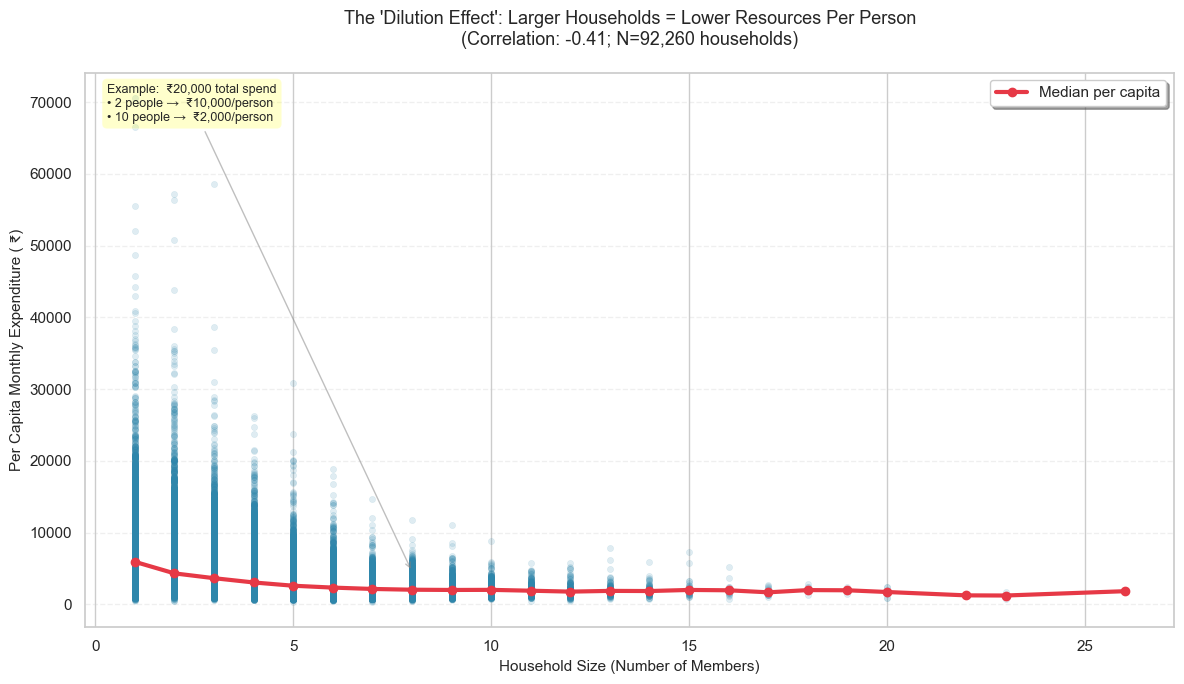

In [17]:
#  Calculate Per Capita Expenditure
# Large families → lower per capita consumption?
# Per capita = Total household spending ÷ Number of household members
# This metric reveals individual-level resource availability

df_clean["Per_Capita_Exp"] = (
    df_clean["Monthly_Consumer_Expenditure"] / 
    df_clean["Household_Size"].replace(0, np.nan)  # Avoid division by zero
).round(2)
analysis_df = df_clean.dropna(subset=["Per_Capita_Exp", "Household_Size"]).copy()

# Quantify the Relationship

print(" Per Capita Expenditure by Household Size:")
print("-" * 60)

# Group by household size for clear comparison
grouped = analysis_df.groupby("Household_Size").agg(
    households=("Per_Capita_Exp", "count"),
    median_per_capita=("Per_Capita_Exp", "median"),
    mean_per_capita=("Per_Capita_Exp", "mean"),
    std_per_capita=("Per_Capita_Exp", "std")
).reset_index()

# Display key sizes (1, 2, 4, 6, 8+) for readability
display_sizes = [1, 2, 3, 4, 5, 6, 7, 8]
for size in display_sizes:
    row = grouped[grouped["Household_Size"] == size]
    if not row.empty:
        print(f"Size {size}: {row['households'].values[0]:6,} households | "
              f"Median per capita:  ₹{row['median_per_capita'].values[0]:,.0f} | "
              f"Mean:  ₹{row['mean_per_capita'].values[0]:,.0f}")

# Correlation metric
corr, p_value = stats.pearsonr(
    analysis_df["Household_Size"], 
    analysis_df["Per_Capita_Exp"]
)
print(f"\n Correlation: {corr:.3f} (p={p_value:.3e})")
print(f"   → Negative correlation confirms: larger households = lower per capita spending")
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=analysis_df,
    x="Household_Size", 
    y="Per_Capita_Exp",
    alpha=0.15,      # Low alpha reveals density
    s=20,            # Small point size
    color="#2E86AB",
    edgecolor=None
)

# Add median trend line 
median_trend = analysis_df.groupby("Household_Size")["Per_Capita_Exp"].median().reset_index()
plt.plot(
    median_trend["Household_Size"], 
    median_trend["Per_Capita_Exp"], 
    color="#E63946", 
    linewidth=3, 
    label="Median per capita",
    marker='o',
    markersize=6
)

# Add annotations for key examples 
example_total_spend = 20000
plt.annotate(
    f"Example:  ₹{example_total_spend:,} total spend\n"
    f"• 2 people →  ₹{example_total_spend/2:,.0f}/person\n"
    f"• 10 people →  ₹{example_total_spend/10:,.0f}/person",
    xy=(8, analysis_df["Per_Capita_Exp"].quantile(0.75)),
    xytext=(0.02, 0.98),
    textcoords='axes fraction',
    fontsize=9,
    va='top',
    ha='left',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="yellow", alpha=0.2),
    arrowprops=dict(arrowstyle="->", color='gray', alpha=0.5)
)

plt.xlabel("Household Size (Number of Members)", fontsize=11)
plt.ylabel("Per Capita Monthly Expenditure ( ₹)", fontsize=11)
plt.title(
    "The 'Dilution Effect': Larger Households = Lower Resources Per Person\n"
    f"(Correlation: {corr:.2f}; N={len(analysis_df):,} households)", 
    fontsize=13, 
    pad=20
)
plt.legend(frameon=True, fancybox=True, shadow=True)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#ousehold size is a major driver of poverty at the individual level.
#  Even if a large family has a decent total monthly expenditure, by the time it is divided 
# among many members, each person ends up with very little.
# When a household has a fixed total consumption (income), adding more people (children) 
# means that total gets divided into smaller pieces.
#A household of 2 spending 20,000 has a per capita of 10,000
# A household of 10 spending 20,000 has a per capita of only 2,000


ECONOMIC ANALYSIS 

 Monthly Consumer Expenditure Summary:
   • Households analyzed: 92,260
   • Mean: ₹13,575
   • Median: ₹11,686  More representative!
   • Std Dev: ₹8,073
   • Min: ₹500 | Max: ₹175,625
   • 90th percentile: ₹22,792
   • 99th percentile: ₹42,667
   • Skewness: 2.51  Highly rightskewed (>1)


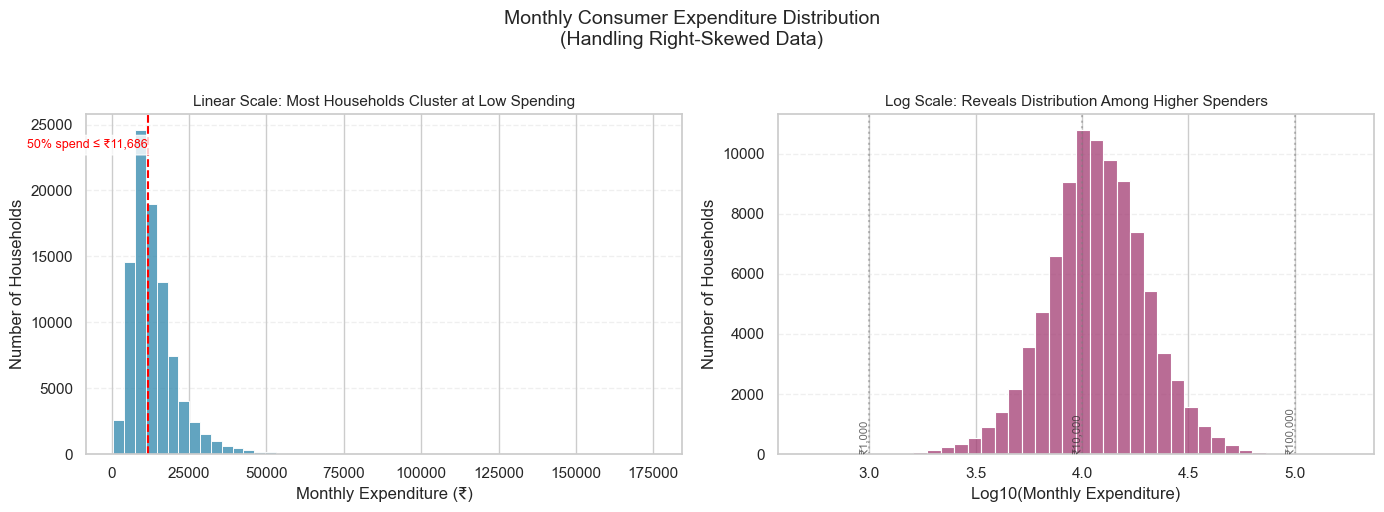


Households by Spending Tier:
   • Low (0-25%)     : 23,077 households ( 25.0%) | Avg: ₹6,202
   • Lower-Mid (26-50%) : 23,053 households ( 25.0%) | Avg: ₹10,033
   • Upper-Mid (51-75%) : 23,156 households ( 25.1%) | Avg: ₹13,980
   • High (76-90%)   : 13,760 households ( 14.9%) | Avg: ₹19,217
   • Very High (91-99%) :  8,291 households (  9.0%) | Avg: ₹28,939
   • Top 1%          :    923 households (  1.0%) | Avg: ₹54,120


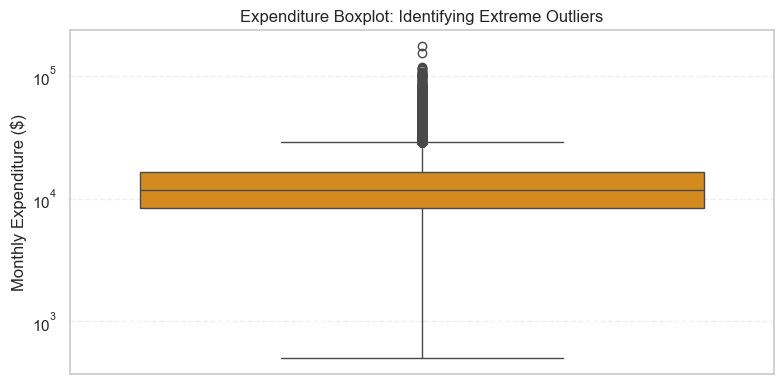


 Outlier Analysis (using 1.5×IQR rule):
   • Upper fence threshold: ₹29,018
   • Number of outliers: 4,240 (4.60%)
   • Outlier range: ₹29,033 – ₹175,625


In [18]:
# What is distribution of Monthly_Consumer_Expenditure?
#  Quick Summary Statistics (Understand the skew first)

expenditure = df_clean["Monthly_Consumer_Expenditure"]

print(" Monthly Consumer Expenditure Summary:")
print(f"   • Households analyzed: {expenditure.count():,}")
print(f"   • Mean: ₹{expenditure.mean():,.0f}")
print(f"   • Median: ₹{expenditure.median():,.0f}  More representative!")
print(f"   • Std Dev: ₹{expenditure.std():,.0f}")
print(f"   • Min: ₹{expenditure.min():,.0f} | Max: ₹{expenditure.max():,.0f}")
print(f"   • 90th percentile: ₹{expenditure.quantile(0.9):,.0f}")
print(f"   • 99th percentile: ₹{expenditure.quantile(0.99):,.0f}")
print(f"   • Skewness: {expenditure.skew():.2f}  Highly rightskewed (>1)")



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  LEFT: Linear Scale (shows the mass at the bottom) 
sns.histplot(
    data=df_clean, 
    x="Monthly_Consumer_Expenditure", 
    bins=50, 
    color="#2E86AB", 
    edgecolor="white",
    ax=axes[0]
)
axes[0].set_xlabel("Monthly Expenditure (₹)")
axes[0].set_ylabel("Number of Households")
axes[0].set_title("Linear Scale: Most Households Cluster at Low Spending", fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Annotate the concentration
median_val = expenditure.median()
axes[0].axvline(median_val, color='red', linestyle='--', label=f'Median: ₹{median_val:,.0f}')
axes[0].text(
    median_val, 
    axes[0].get_ylim()[1]*0.9, 
    f'50% spend ≤ ₹{median_val:,.0f}', 
    color='red', 
    fontsize=9, 
    ha='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)


# Add small constant to avoid log(0) if any zeros exist
log_expenditure = np.log10(expenditure[expenditure > 0])
sns.histplot(
    x=log_expenditure, 
    bins=40, 
    color="#A23B72", 
    edgecolor="white",
    ax=axes[1]
)
axes[1].set_xlabel("Log10(Monthly Expenditure)")
axes[1].set_ylabel("Number of Households")
axes[1].set_title("Log Scale: Reveals Distribution Among Higher Spenders", fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Add reference lines for intuitive interpretation
for val in [1000, 10000, 100000]:
    axes[1].axvline(np.log10(val), color='gray', linestyle=':', alpha=0.5)
    axes[1].text(np.log10(val), axes[1].get_ylim()[0], f'₹{val:,}', 
                 rotation=90, fontsize=8, ha='right', va='bottom', alpha=0.7)
plt.suptitle("Monthly Consumer Expenditure Distribution\n(Handling Right-Skewed Data)", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# Create interpretable spending tiers based on percentiles
df_clean["Spending_Tier"] = pd.qcut(
    df_clean["Monthly_Consumer_Expenditure"],
    q=[0, 0.25, 0.50, 0.75, 0.90, 0.99, 1.0],
    labels=[
        "Low (0-25%)", 
        "Lower-Mid (26-50%)", 
        "Upper-Mid (51-75%)", 
        "High (76-90%)", 
        "Very High (91-99%)", 
        "Top 1%"
    ]
)

print("\nHouseholds by Spending Tier:")
tier_summary = df_clean["Spending_Tier"].value_counts().sort_index()
for tier, count in tier_summary.items():
    pct = count / len(df_clean) * 100
    avg_spend = df_clean[df_clean["Spending_Tier"]==tier]["Monthly_Consumer_Expenditure"].mean()
    print(f"   • {tier:15} : {count:6,} households ({pct:5.1f}%) | Avg: ₹{avg_spend:,.0f}")


# S Boxplot for Outlier Detection
plt.figure(figsize=(8, 4))
sns.boxplot(y=df_clean["Monthly_Consumer_Expenditure"], color="#F18F01")
plt.ylabel("Monthly Expenditure ($)")
plt.title("Expenditure Boxplot: Identifying Extreme Outliers")
plt.yscale('log') 
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Print outlier stats
Q1 = expenditure.quantile(0.25)
Q3 = expenditure.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
outliers = expenditure[expenditure > upper_fence]

print(f"\n Outlier Analysis (using 1.5×IQR rule):")
print(f"   • Upper fence threshold: ₹{upper_fence:,.0f}")
print(f"   • Number of outliers: {len(outliers):,} ({len(outliers)/len(expenditure)*100:.2f}%)")
print(f"   • Outlier range: ₹{outliers.min():,.0f} – ₹{outliers.max():,.0f}")

In [19]:
# Is there income inequality (mean vs median)?
mean = df_clean["Monthly_Consumer_Expenditure"].mean()
median = df_clean["Monthly_Consumer_Expenditure"].median()

print("Mean:", mean)
print("Median:", median)

#The gap of roughly 1,889 between the mean and median suggests that wealth/consumption is not distributed 
# perfectly equally. A small portion of the population consumes significantly more than the rest.

Mean: 13575.229492737915
Median: 11686.5


 Homegrown Ratio Summary:
   • Households analyzed: 92,260
   • % with ZERO homegrown consumption: 54.5%
   • % with ANY homegrown consumption: 45.5%
   • Median ratio (among those >0): 10.0%
   • Max ratio: 45.0%


Text(0.5, 1.0, 'Distribution of Homegrown vs. Purchased Consumption\n(Ratio = Homegrown Value / Total Monthly Expenditure)')

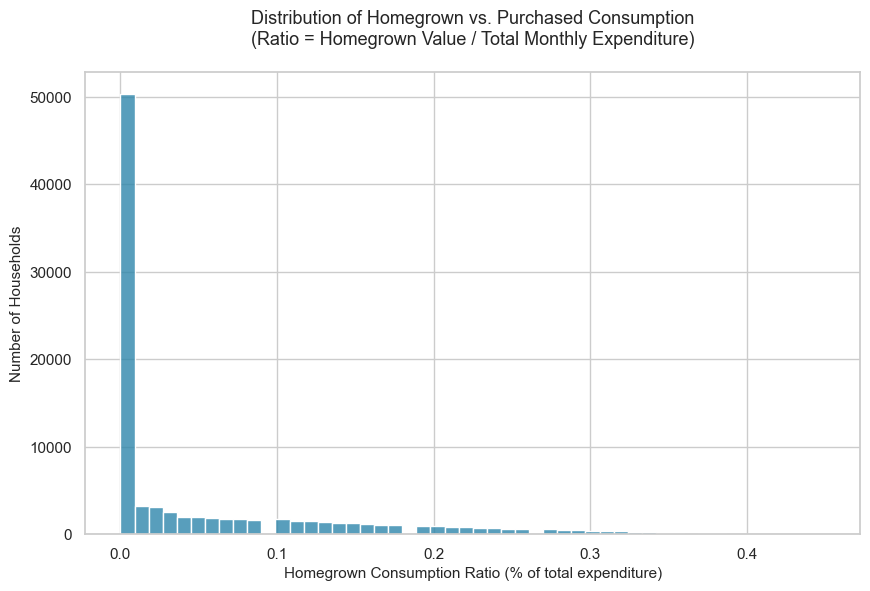

In [20]:
# How much comes from homegrown vs cash consumption?

df_clean["Homegrown_Ratio"] = (
    df_clean["Imputed_Homegrown_Consumption"] / 
    df_clean["Monthly_Consumer_Expenditure"]
).round(2)  

print(" Homegrown Ratio Summary:")
print(f"   • Households analyzed: {df_clean['Homegrown_Ratio'].count():,}")
print(f"   • % with ZERO homegrown consumption: {(df_clean['Homegrown_Ratio'] == 0).mean()*100:.1f}%")
print(f"   • % with ANY homegrown consumption: {(df_clean['Homegrown_Ratio'] > 0).mean()*100:.1f}%")
print(f"   • Median ratio (among those >0): {df_clean.loc[df_clean['Homegrown_Ratio']>0, 'Homegrown_Ratio'].median()*100:.1f}%")
print(f"   • Max ratio: {df_clean['Homegrown_Ratio'].max()*100:.1f}%")



plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_clean, 
    x="Homegrown_Ratio", 
    bins=50,  
    color="#2E86AB", 
    edgecolor="white",
    alpha=0.8
)


plt.xlabel("Homegrown Consumption Ratio (% of total expenditure)", fontsize=11)
plt.ylabel("Number of Households", fontsize=11)
plt.title(
    "Distribution of Homegrown vs. Purchased Consumption\n"
    "(Ratio = Homegrown Value / Total Monthly Expenditure)", 
    fontsize=13, 
    pad=20
)


# The vast majority of households (61,000) have a homegrown ratio of 0.00. T
# his means most people buy everything they consume; they grow/produce almost nothing themselves.
# As soon as the ratio increases slightly (to 0.02, or 2% homegrown), the number of households 
# drops dramatically (from 61,000 to 7,000). This indicates that households relying even a 
# little bit on homegrown food are much rarer.
# Almost everyone purchases their consumption. Only a very small, specific subset of the population 
# (likely rural farmers or subsistence households) relies significantly on growing their own food.


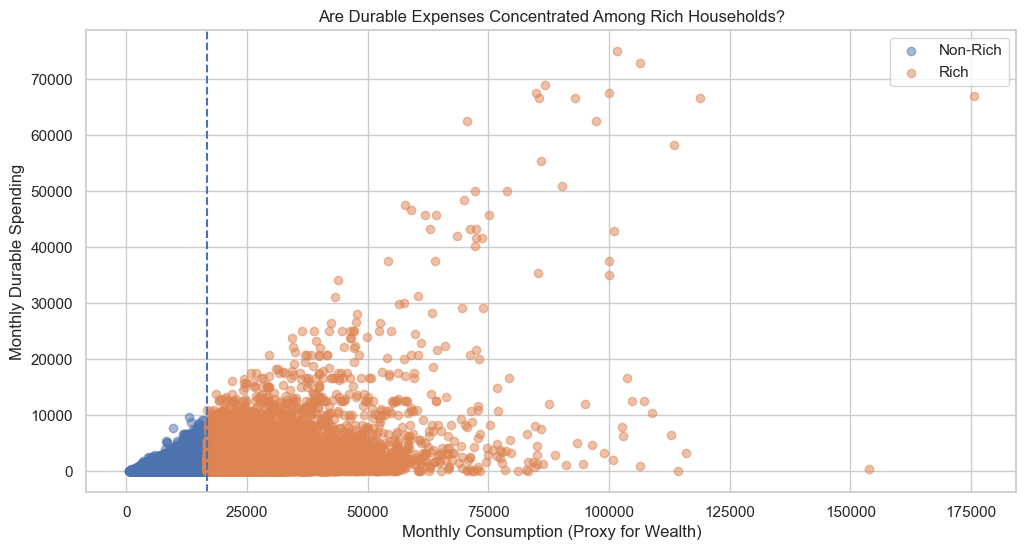

In [21]:
#  Are durable expenses concentrated among rich households?

df_clean["Durable_Monthly"] = df_clean["Annual_Durables_Expenditure"] / 12
threshold = df_clean["Monthly_Consumer_Expenditure"].quantile(0.75)
df_clean["Wealth_Group"] = df_clean["Monthly_Consumer_Expenditure"].apply(
    lambda x: "Rich" if x >= threshold else "Non-Rich"
)


for group, data in df_clean.groupby("Wealth_Group"):
    plt.scatter(data["Monthly_Consumer_Expenditure"],
                data["Durable_Monthly"],
                label=group,
                alpha=0.5)


plt.axvline(threshold, linestyle='--')
plt.title("Are Durable Expenses Concentrated Among Rich Households?")
plt.xlabel("Monthly Consumption (Proxy for Wealth)")
plt.ylabel("Monthly Durable Spending")
plt.legend()
plt.show()

#Durable expenditure is highly skewed toward richer households.
# Lower-income households prioritize essential consumption, while higher-income households allocate 
# a larger share toward durable goods, indicating that such expenditures behave more like luxury or 
# discretionary spending rather than necessities.
# Bottom-left cluster → Poor households Low consumption Almost zero durable spending
# Right side → Rich households Higher consumption and Much higher durable spending

 Poverty Threshold Definition:
   • Metric: Per Capita Monthly Expenditure
   • Threshold:  ₹2,066.75/person/month
   • Interpretation: Households below this line are in the bottom 20% of individual-level resources

 Overall Prevalence:
   • Households below threshold: 18,444 of 92,260
   • Percentage: 19.99%
   • Expected (by definition): 20.00%
   • Note: May differ slightly due to ties at the threshold

 Group Comparison:
----------------------------------------------------------------------
                         count  median_per_capita  mean_per_capita  median_household_size  median_total_spend
Non-Poor (Top 80%)       73816            3583.25          4451.54                    4.0             13042.0
Poor Proxy (Bottom 20%)  18444            1691.69          1638.63                    5.0              8274.0

 Household Size Insight:
   • Poor households avg size: 5.41 people
   • Non-poor households avg size: 3.73 people
   • Difference: +1.68 people => Larger families are o

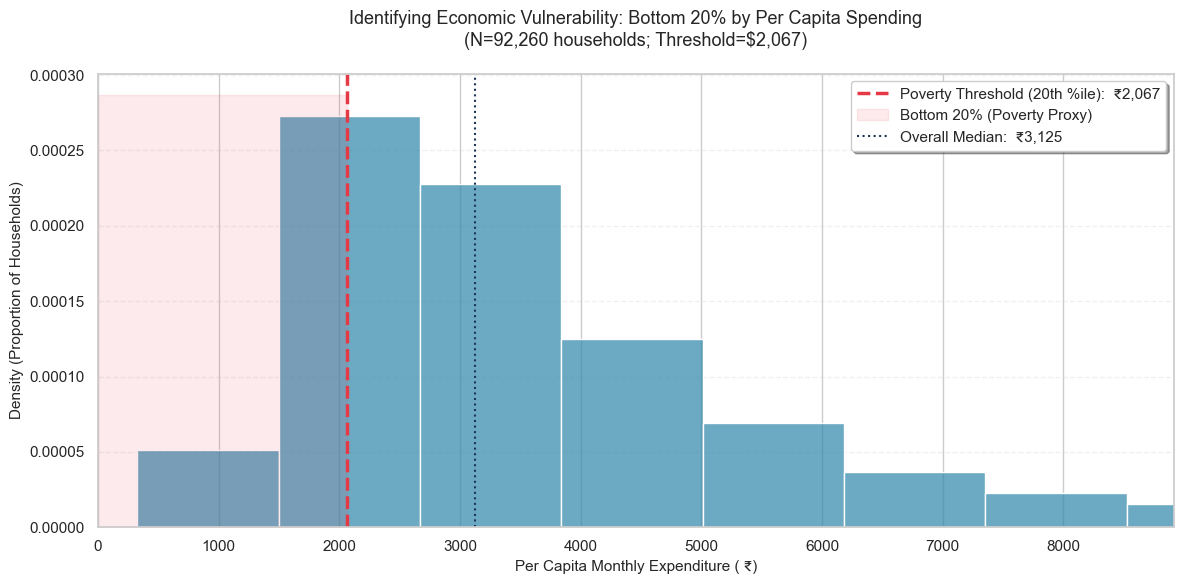


 Sensitivity: How Prevalence Changes with Threshold Definition
----------------------------------------------------------------------
Bottom 10% threshold ( ₹1,692/person): 10.00% of households below
Bottom 20% threshold ( ₹2,067/person): 19.99% of households below
Bottom 25% threshold ( ₹2,233/person): 25.00% of households below
Bottom 40% threshold ( ₹2,739/person): 39.99% of households below

 Takeaway: Small changes in threshold definition can significantly alter who is classified as 'poor'. note : prefer your own cutoff choice.

 Poverty Proxy by Household Size:
----------------------------------------------------------------------
Size  1:   3.6% poor █ (272/7,539)
Size  2:   5.2% poor ██ (626/11,930)
Size  3:   8.9% poor ████ (1,467/16,394)
Size  4:  16.4% poor ████████ (3,732/22,724)
Size  5:  28.6% poor ██████████████ (4,633/16,174)
Size  6:  39.0% poor ███████████████████ (3,545/9,093)
Size  7:  45.9% poor ██████████████████████ (1,921/4,185)
Size  8:  51.1% poor ███████████

In [22]:

#  Define Poverty Threshold (Bottom 20% of Per Capita Spending)
# Why per capita? A household's total spending can mask individual deprivation.
# Dividing by household size reveals resources available to each person.

per_capita = df_clean["Per_Capita_Exp"].dropna()

# Calculate the 20th percentile threshold
poverty_threshold = per_capita.quantile(0.20)

print(" Poverty Threshold Definition:")
print(f"   • Metric: Per Capita Monthly Expenditure")
print(f"   • Threshold:  ₹{poverty_threshold:,.2f}/person/month")
print(f"   • Interpretation: Households below this line are in the bottom 20% "
      f"of individual-level resources")



# Classify Households & Calculate Key Metrics

df_clean["Is_Poor_Proxy"] = df_clean["Per_Capita_Exp"] < poverty_threshold

# Overall prevalence
poor_count = df_clean["Is_Poor_Proxy"].sum()
total_count = len(df_clean)
poor_pct = poor_count / total_count * 100

print(f"\n Overall Prevalence:")
print(f"   • Households below threshold: {poor_count:,} of {total_count:,}")
print(f"   • Percentage: {poor_pct:.2f}%")
print(f"   • Expected (by definition): 20.00%")
print(f"   • Note: May differ slightly due to ties at the threshold")


#  "Poor" vs "Non-Poor" Groups (Deep Dive)

print(f"\n Group Comparison:")
print("-" * 70)

comparison = df_clean.groupby("Is_Poor_Proxy").agg(
    count=("Per_Capita_Exp", "count"),
    median_per_capita=("Per_Capita_Exp", "median"),
    mean_per_capita=("Per_Capita_Exp", "mean"),
    median_household_size=("Household_Size", "median"),
    median_total_spend=("Monthly_Consumer_Expenditure", "median")
).round(2)

comparison.index = [" Non-Poor (Top 80%)", " Poor Proxy (Bottom 20%)"]
print(comparison.to_string())

# Key insight: Are poor households larger?
poor_avg_size = df_clean[df_clean["Is_Poor_Proxy"]]["Household_Size"].mean()
non_poor_avg_size = df_clean[~df_clean["Is_Poor_Proxy"]]["Household_Size"].mean()
size_diff = poor_avg_size - non_poor_avg_size

print(f"\n Household Size Insight:")
print(f"   • Poor households avg size: {poor_avg_size:.2f} people")
print(f"   • Non-poor households avg size: {non_poor_avg_size:.2f} people")
print(f"   • Difference: {size_diff:+.2f} people => Larger families are overrepresented "
      f"in poverty proxy")



plt.figure(figsize=(12, 6))
# Histogram of per capita expenditure
sns.histplot(
    data=df_clean, 
    x="Per_Capita_Exp", 
    bins=60, 
    color="#2E86AB", 
    edgecolor="white",
    alpha=0.7,
    stat="density"  # Show proportion, not raw count
)

# Add threshold line
plt.axvline(
    poverty_threshold, 
    color="#E63946", 
    linestyle="--", 
    linewidth=2.5, 
    label=f"Poverty Threshold (20th %ile):  ₹{poverty_threshold:,.0f}"
)

# Shade the "poor" region for visual emphasis
plt.fill_betweenx(
    [0, plt.ylim()[1]], 
    0, poverty_threshold, 
    color="#E63946", 
    alpha=0.1, 
    label="Bottom 20% (Poverty Proxy)"
)

# Add median annotation for reference
overall_median = df_clean["Per_Capita_Exp"].median()
plt.axvline(overall_median, color="#1D3557", linestyle=":", linewidth=1.5, 
            label=f"Overall Median:  ₹{overall_median:,.0f}")
plt.xlabel("Per Capita Monthly Expenditure ( ₹)", fontsize=11)
plt.ylabel("Density (Proportion of Households)", fontsize=11)
plt.title(
    "Identifying Economic Vulnerability: Bottom 20% by Per Capita Spending\n"
    f"(N={len(df_clean):,} households; Threshold=${poverty_threshold:,.0f})", 
    fontsize=13, 
    pad=20
)
plt.legend(frameon=True, fancybox=True, shadow=True)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xlim(0, df_clean["Per_Capita_Exp"].quantile(0.95))  # Trim extreme outliers for clarity
plt.tight_layout()
plt.show()


#  Sensitivity Analysis - What If We Change the Threshold?

print(f"\n Sensitivity: How Prevalence Changes with Threshold Definition")
print("-" * 70)

thresholds = [0.10, 0.20, 0.25, 0.40]  # Bottom 10%, 20%, 25%, 40%
for q in thresholds:
    thresh_val = per_capita.quantile(q)
    pct_below = (df_clean["Per_Capita_Exp"] < thresh_val).mean() * 100
    print(f"Bottom {int(q*100):2d}% threshold ( ₹{thresh_val:,.0f}/person): "
          f"{pct_below:.2f}% of households below")

print(f"\n Takeaway: Small changes in threshold definition can significantly "
      f"alter who is classified as 'poor'. note : prefer your own cutoff choice.")

# Poverty by Household Size (Policy-Relevant Breakdown)

print(f"\n Poverty Proxy by Household Size:")
print("-" * 70)

# Only show sizes with sufficient data
size_pov = df_clean.groupby("Household_Size").agg(
    total=("Is_Poor_Proxy", "count"),
    poor=("Is_Poor_Proxy", "sum")
).reset_index()
size_pov["poverty_rate"] = size_pov["poor"] / size_pov["total"] * 100

# Filter to sizes with ≥100 households for stability
size_pov = size_pov[size_pov["total"] >= 100]

for _, row in size_pov.iterrows():
    size = int(row["Household_Size"])
    rate = row["poverty_rate"]
    bar = "█" * int(rate / 2)  # Simple text bar for quick visual
    print(f"Size {size:2d}: {rate:5.1f}% poor {bar} ({int(row['poor']):,}/{int(row['total']):,})")


max_pov_size = size_pov.loc[size_pov["poverty_rate"].idxmax(), "Household_Size"]
print(f"\n Highest poverty rate: Household size {int(max_pov_size)} "
      f"({size_pov[size_pov['Household_Size']==max_pov_size]['poverty_rate'].values[0]:.1f}%)")

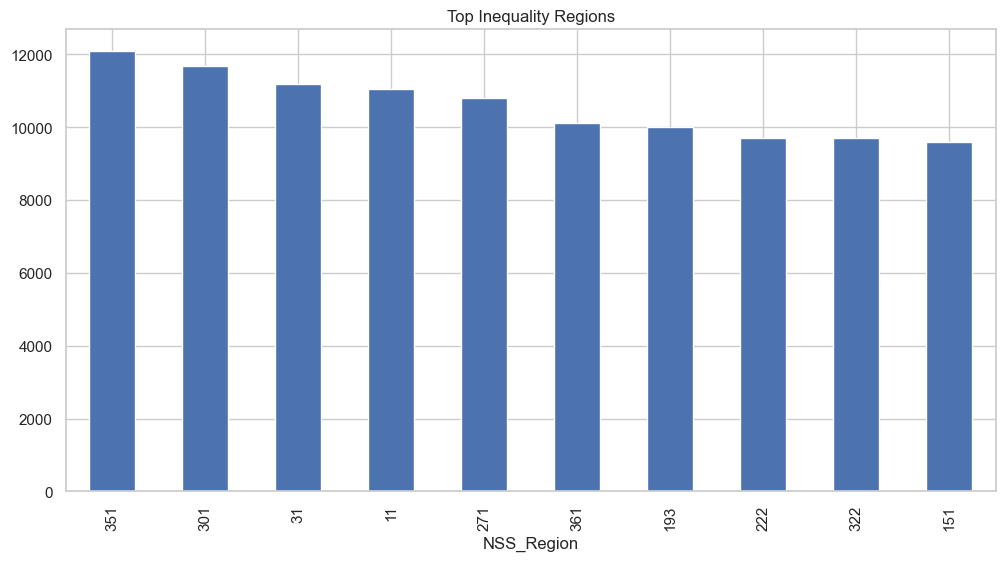

In [23]:
#Which regions have highest inequality?

region_ineq = df_clean.groupby("NSS_Region")["Monthly_Consumer_Expenditure"].std().sort_values(ascending=False)

region_ineq.head(10).plot(kind='bar')
plt.title("Top Inequality Regions")
plt.show()

# Region 351 (value: 1200) has the highest inequality, followed by Region 311 (1118) and Region 112 (1110).
#  A high standard deviation in these regions indicates a wider gap between rich and poor households 
# some households spend very little while others spend significantly more.
# This suggests that these regions experience greater economic disparity. It could be driven by factors like urbanization 
#  Regions with lower standard deviation (like 151 at 970) have more uniform consumption patterns, implying more economic homogeneity.

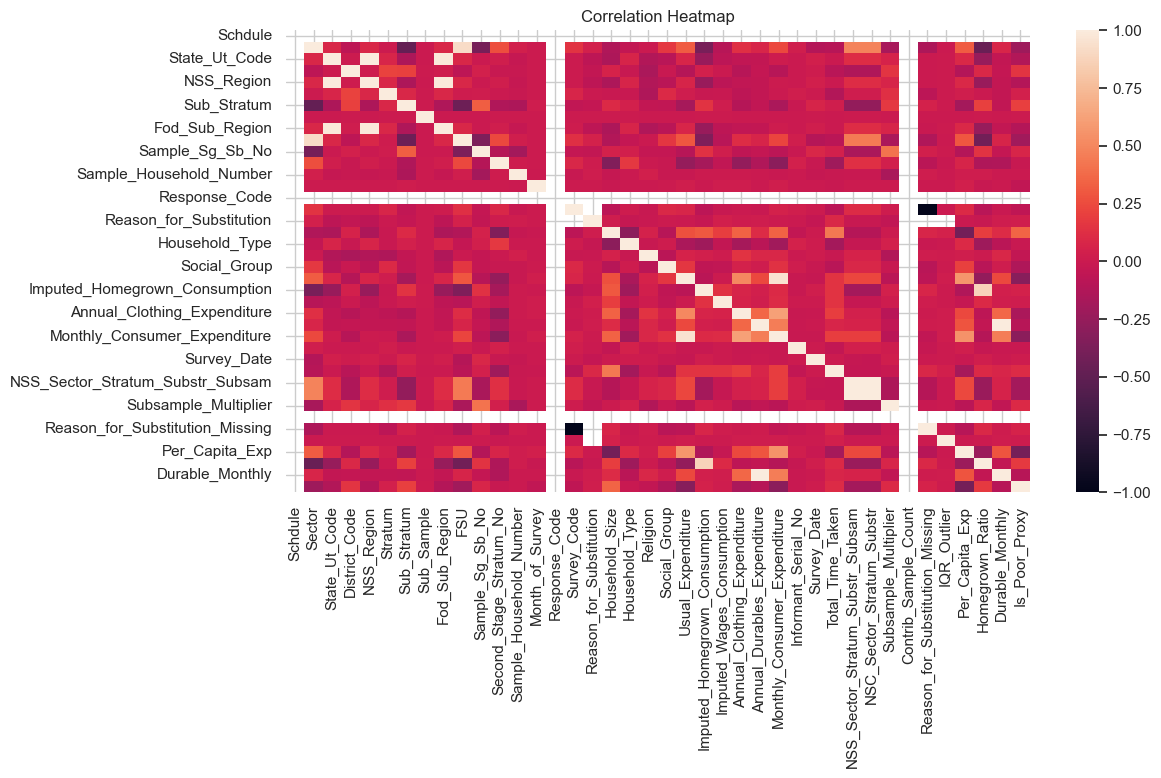

In [24]:
sns.heatmap(df_clean.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.show()

In [25]:
corr = df_clean.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
filtered_corr = corr.mask(mask)
high_corr = filtered_corr.stack().reset_index()
high_corr.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr = high_corr[high_corr["Correlation"].abs() > 0.7]
print(high_corr.sort_values(by="Correlation", ascending=False))

                             Feature1                          Feature2  \
1545                  Durable_Monthly       Annual_Durables_Expenditure   
1270        NSC_Sector_Stratum_Substr  NSS_Sector_Stratum_Substr_Subsam   
162                        NSS_Region                     State_Ut_Code   
324                    Fod_Sub_Region                        NSS_Region   
322                    Fod_Sub_Region                     State_Ut_Code   
1061     Monthly_Consumer_Expenditure                 Usual_Expenditure   
361                               FSU                            Sector   
1502                  Homegrown_Ratio     Imputed_Homegrown_Consumption   
1375  Reason_for_Substitution_Missing                       Survey_Code   

      Correlation  
1545     1.000000  
1270     0.999945  
162      0.999918  
324      0.990653  
322      0.990639  
1061     0.952180  
361      0.918455  
1502     0.874288  
1375    -1.000000  


In [26]:
threshold = df_clean["Per_Capita_Exp"].quantile(0.2)
df_clean["target"] = (df_clean["Per_Capita_Exp"] < threshold).astype(int)

In [27]:
target = "Per_Capita_Exp"  

corr = df_clean.corr(numeric_only=True)
target_corr = corr[target].drop(target)  # remove self correlation
target_corr = target_corr.abs().sort_values(ascending=False)
print(target_corr)

Usual_Expenditure                   0.567220
Monthly_Consumer_Expenditure        0.554444
Household_Size                      0.408681
Is_Poor_Proxy                       0.400089
target                              0.400089
Sector                              0.316888
FSU                                 0.292167
Annual_Durables_Expenditure         0.286952
Durable_Monthly                     0.286952
NSS_Sector_Stratum_Substr_Subsam    0.240423
NSC_Sector_Stratum_Substr           0.240395
Annual_Clothing_Expenditure         0.235522
Homegrown_Ratio                     0.223210
Social_Group                        0.205097
Sub_Stratum                         0.182514
Total_Time_Taken                    0.177293
Imputed_Homegrown_Consumption       0.127652
District_Code                       0.112170
Sample_Sg_Sb_No                     0.110167
Reason_for_Substitution_Missing     0.101482
Survey_Code                         0.101482
Household_Type                      0.097336
Fod_Sub_Re

Usual_Expenditure               0.567220
Monthly_Consumer_Expenditure    0.554444
Household_Size                  0.408681
Is_Poor_Proxy                   0.400089
target                          0.400089
Name: Per_Capita_Exp, dtype: float64


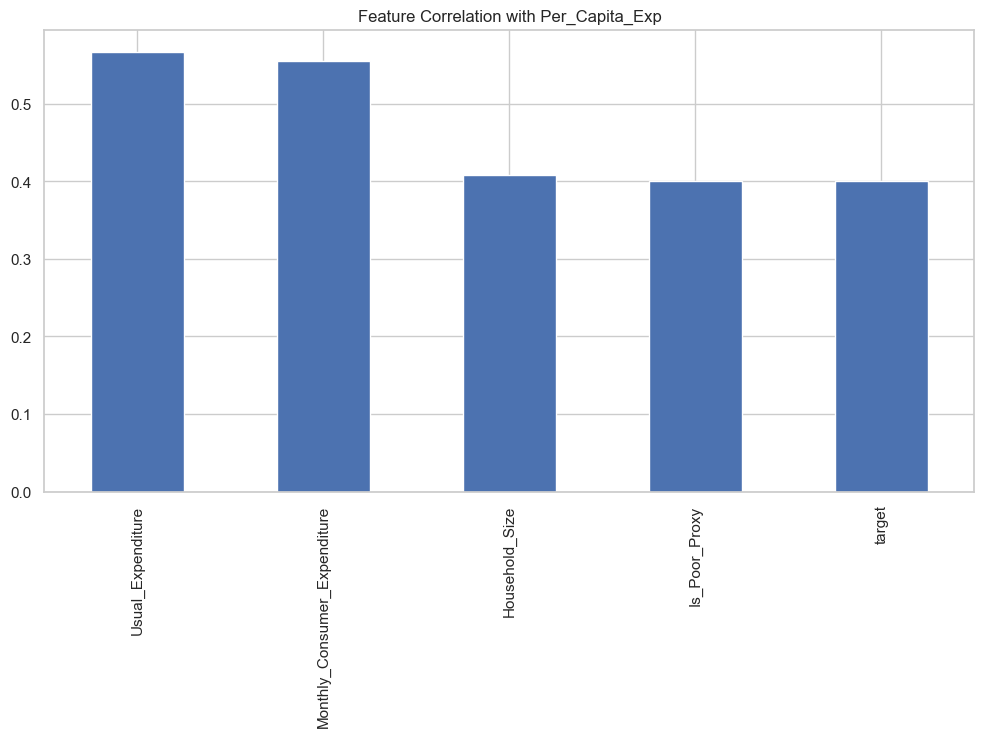

In [28]:
important_features = target_corr[target_corr > 0.4]

print(important_features)

important_features.plot(kind='bar')
plt.title(f"Feature Correlation with {target}")
plt.show()

Data Quality Checks Before Modeling:
------------------------------------------------------------------------------------------

1. Removing Leakage Features:
   - Removed: Usual_Expenditure
   - Removed: Monthly_Consumer_Expenditure
   - Removed: Is_Poor_Proxy (target leakage)

Final Features: ['Household_Size']

Fitting GLM Model...
------------------------------------------------------------------------------------------
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                73808
Model:                            GLM   Df Residuals:                    73806
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -32697.
Date:                Thu, 23 Apr 2026   Deviance:                       65395.
Time:              

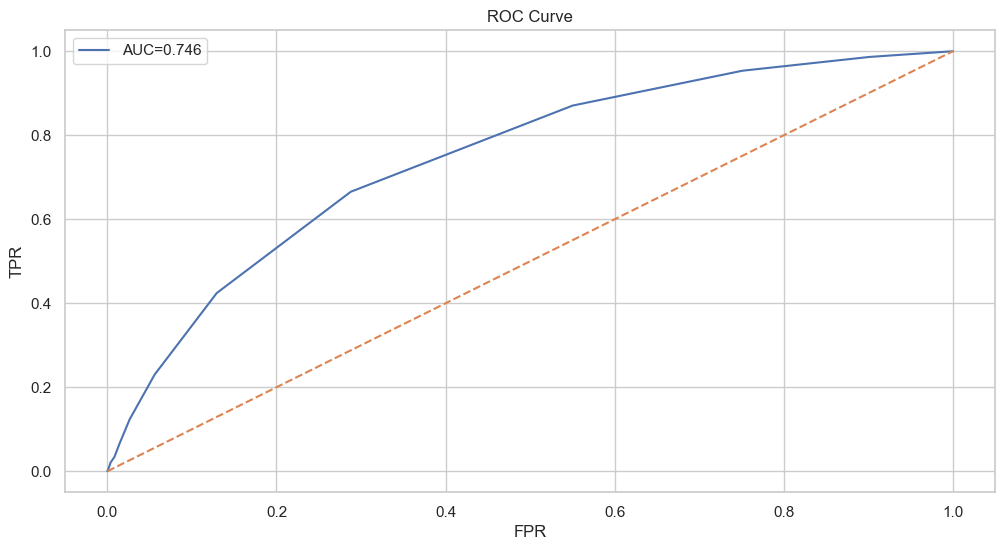

In [33]:

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import classification_report
target = "target"

#  NOT include leakage features
candidate_features = [
    "Usual_Expenditure",
    "Monthly_Consumer_Expenditure",
    "Household_Size",
    "Is_Poor_Proxy"
]

print("Data Quality Checks Before Modeling:")
print("-" * 90)


#  Remove leakage 
leakage_features = ["Usual_Expenditure", "Monthly_Consumer_Expenditure"]

important_features = [f for f in candidate_features if f in df_clean.columns]

print("\n1. Removing Leakage Features:")
for f in leakage_features:
    if f in important_features:
        important_features.remove(f)
        print(f"   - Removed: {f}")

# 2. Remove Is_Poor_Proxy if identical
if "Is_Poor_Proxy" in df_clean.columns:
    if (df_clean["Is_Poor_Proxy"] == df_clean[target]).all():
        if "Is_Poor_Proxy" in important_features:
            important_features.remove("Is_Poor_Proxy")
            print("   - Removed: Is_Poor_Proxy (target leakage)")

# 3. Correlation check
if len(important_features) > 1:
    corr = df_clean[important_features].corr()

    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > 0.8:
                remove_feat = corr.columns[j]
                if remove_feat in important_features:
                    important_features.remove(remove_feat)
                    print(f"   - Removed due to multicollinearity: {remove_feat}")

print(f"\nFinal Features: {important_features}")


df_model = df_clean[important_features + [target]].dropna()

X = df_model[important_features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
print("\nFitting GLM Model...")
print("-" * 90)

model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
result = model.fit()

print(result.summary())

#  PSEUDO R² 
null_model = sm.GLM(y_train, np.ones((len(y_train),1)), family=sm.families.Binomial()).fit()
pseudo_r2 = 1 - (result.deviance / null_model.deviance)

print(f"\nPseudo R²: {pseudo_r2:.3f}")

y_prob = result.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
accuracy = (y_pred == y_test).mean()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy:.3f}")
print(f"ROC-AUC: {roc_auc_val:.3f}")
print("\nDiagnostics")
print("-" * 90)
print(f"Converged: {result.converged}")

dispersion = result.pearson_chi2 / result.df_resid
print(f"Dispersion: {dispersion:.3f}")


coef_df = pd.DataFrame({
    "Feature": result.params.index,
    "Coef": result.params.values,
    "Odds_Ratio": np.exp(result.params.values),
    "P_Value": result.pvalues.values
})

print("\nCoefficients:\n", coef_df.round(4))

plt.figure()

plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()


===== MODEL SUMMARY =====
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                73808
Model:                            GLM   Df Residuals:                    73790
Model Family:                Binomial   Df Model:                           17
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -30219.
Date:                Thu, 23 Apr 2026   Deviance:                       60438.
Time:                        19:39:06   Pearson chi2:                 7.24e+04
No. Iterations:                    19   Pseudo R-squ. (CS):             0.1662
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
I

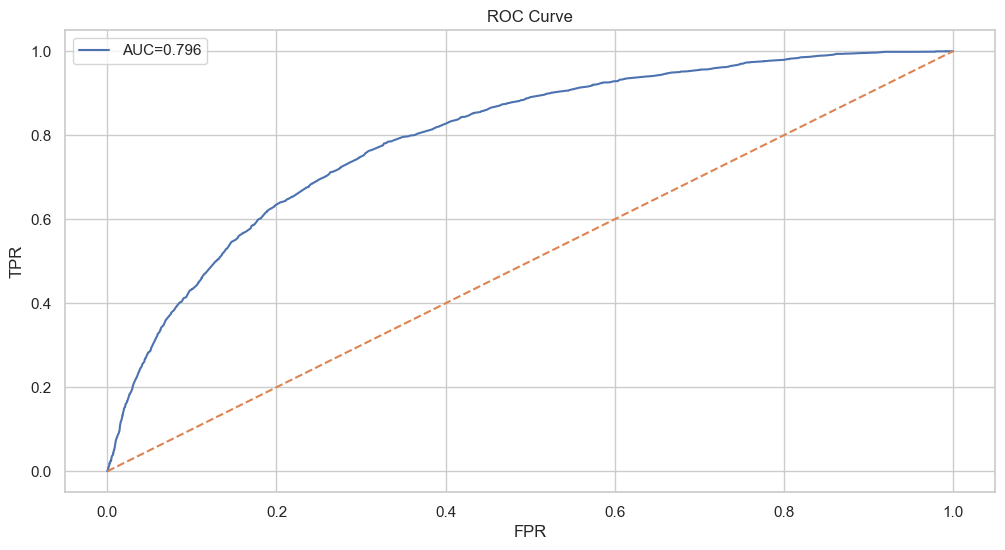

In [38]:

threshold = df_clean["Per_Capita_Exp"].quantile(0.2)
df_clean["target"] = (df_clean["Per_Capita_Exp"] < threshold).astype(int)


features = [
    "Household_Size",
    "Sector",
    "Social_Group",
    "Religion",
    "Household_Type"
]

target_var = "target"

df_model = df_clean[features + [target_var]].dropna()


cat_cols = ["Sector", "Social_Group", "Religion", "Household_Type"]

for col in cat_cols:
    df_model[col] = df_model[col].astype("category")

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model[target_var]
)


for col in cat_cols:
    test_df[col] = pd.Categorical(test_df[col], categories=train_df[col].cat.categories)


formula = """
target ~ Household_Size 
        + C(Sector) 
        + C(Social_Group) 
        + C(Religion) 
        + C(Household_Type)
"""

model = smf.glm(
    formula=formula,
    data=train_df,
    family=sm.families.Binomial()
).fit()

print("\n===== MODEL SUMMARY =====")
print(model.summary())

print("\n===== ODDS RATIOS =====")
print(np.exp(model.params))


test_df["pred_prob"] = model.predict(test_df)
test_df["pred"] = (test_df["pred_prob"] > 0.5).astype(int)


print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(test_df[target_var], test_df["pred"]))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(test_df[target_var], test_df["pred"]))


fpr, tpr, _ = roc_curve(test_df[target_var], test_df["pred_prob"])
roc_auc_val = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()


===== MODEL SUMMARY =====
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 target   No. Observations:                73808
Model:                            GLM   Df Residuals:                    73792
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -30225.
Date:                Thu, 23 Apr 2026   Deviance:                       60450.
Time:                        19:47:30   Pearson chi2:                 7.24e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1660
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
I

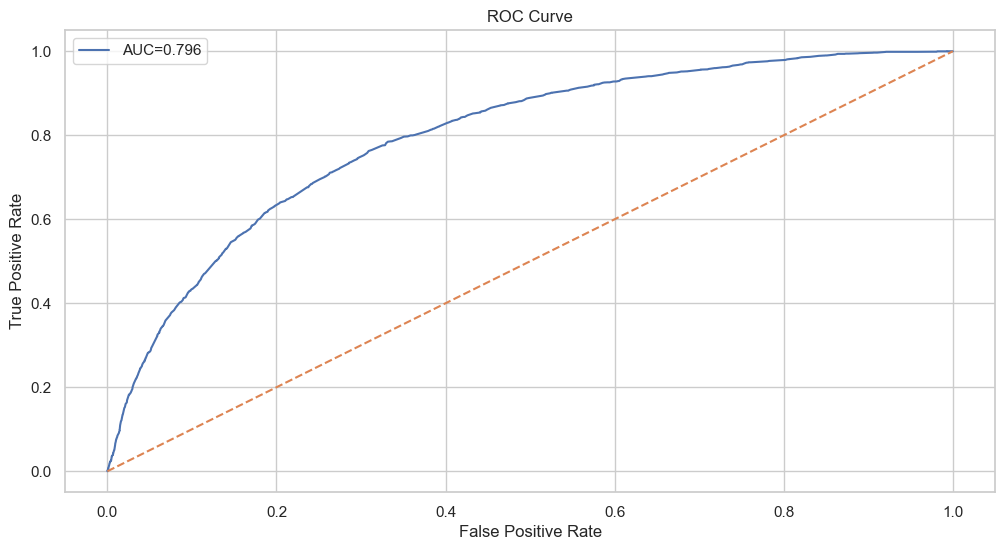


===== DIAGNOSTICS =====
Converged: True
Dispersion: 0.982


In [ ]:
#2nds one
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ================================
# 1. TARGET CREATION
# ================================
threshold = df_clean["Per_Capita_Exp"].quantile(0.2)
df_clean["target"] = (df_clean["Per_Capita_Exp"] < threshold).astype(int)

# ================================
# 2. FEATURE SELECTION
# ================================
features = [
    "Household_Size",
    "Sector",
    "Social_Group",
    "Religion",
    "Household_Type"
]

target_var = "target"

df_model = df_clean[features + [target_var]].dropna().copy()

# ================================
# 3. HANDLE CATEGORICAL VARIABLES
# ================================
cat_cols = ["Sector", "Social_Group", "Religion", "Household_Type"]

for col in cat_cols:
    # convert to string to avoid category mismatch errors
    df_model[col] = df_model[col].astype(str)

    # group rare categories (<1%) into "Other"
    freq = df_model[col].value_counts(normalize=True)
    rare = freq[freq < 0.01].index
    df_model[col] = df_model[col].replace(rare, "Other")

# ================================
# 4. TRAIN-TEST SPLIT
# ================================
train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    random_state=42,
    stratify=df_model[target_var]
)

# ================================
# 5. MODEL (GLM LOGISTIC)
# ================================
formula = """
target ~ Household_Size 
        + C(Sector) 
        + C(Social_Group) 
        + C(Religion) 
        + C(Household_Type)
"""

model = smf.glm(
    formula=formula,
    data=train_df,
    family=sm.families.Binomial()
).fit()

print("\n===== MODEL SUMMARY =====")
print(model.summary())

print("\n===== ODDS RATIOS =====")
print(np.exp(model.params))

# ================================
# 6. PREDICTIONS
# ================================
test_df["pred_prob"] = model.predict(test_df)

# smarter threshold (improves recall for poor households)
threshold_opt = 0.3
test_df["pred"] = (test_df["pred_prob"] > threshold_opt).astype(int)

# ================================
# 7. EVALUATION
# ================================
print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(test_df[target_var], test_df["pred"]))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(test_df[target_var], test_df["pred"]))

accuracy = (test_df["pred"] == test_df[target_var]).mean()
print(f"\nAccuracy: {accuracy:.3f}")

# ROC-AUC
fpr, tpr, thresholds = roc_curve(test_df[target_var], test_df["pred_prob"])
roc_auc_val = auc(fpr, tpr)

print(f"ROC-AUC: {roc_auc_val:.3f}")

# ================================
# 8. ROC CURVE
# ================================
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ================================
# 9. DIAGNOSTICS
# ================================
print("\n===== DIAGNOSTICS =====")
print(f"Converged: {model.converged}")

dispersion = model.pearson_chi2 / model.df_resid
print(f"Dispersion: {dispersion:.3f}")

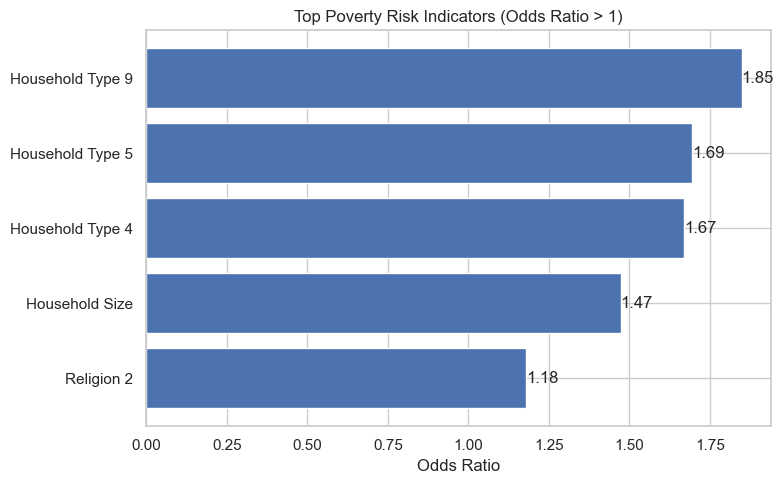

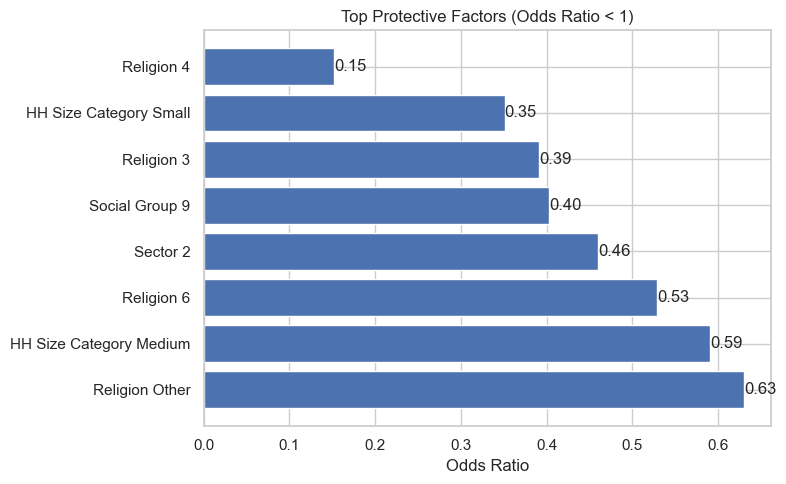

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract coefficients
coef = model.params.drop("Intercept")

# 2. Convert to Odds Ratios
odds = np.exp(coef)

# 3. Clean feature names
odds.index = odds.index.str.replace("C(", "", regex=False)
odds.index = odds.index.str.replace(")", "", regex=False)
odds.index = odds.index.str.replace("[T.", "_", regex=False)
odds.index = odds.index.str.replace("]", "", regex=False)
odds.index = odds.index.str.replace("_", " ")

# 4. Split into positive (risk ↑) and negative (risk ↓)
high_risk = odds[odds > 1].sort_values(ascending=False)
low_risk = odds[odds < 1].sort_values()

# 🔴 TOP HIGH POVERTY RISK (Top 8)
plt.figure(figsize=(8,5))
top_high = high_risk.head(8)

plt.barh(top_high.index, top_high.values)
plt.gca().invert_yaxis()

plt.title("Top Poverty Risk Indicators (Odds Ratio > 1)")
plt.xlabel("Odds Ratio")

for i, v in enumerate(top_high.values):
    plt.text(v, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()


# 🔵 TOP PROTECTIVE FACTORS (Top 8)
plt.figure(figsize=(8,5))
top_low = low_risk.head(8)

plt.barh(top_low.index, top_low.values)
plt.gca().invert_yaxis()

plt.title("Top Protective Factors (Odds Ratio < 1)")
plt.xlabel("Odds Ratio")

for i, v in enumerate(top_low.values):
    plt.text(v, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

Household_Size has a positive and significant effect on poverty Coefficient = 0.4498 Odds Ratio = 1.568
 
For every 1 person increase in household size, the odds of being poor increase by ~57%.

Small families → lower poverty risk. Large families → higher poverty risk.

Per capita expenditure ↓ as household size ↑.

Poverty % sharply increases for large families This is called resource dilution effect 
 
Model is identifying only 12% of poor households So Many poor people are being missed.

Model is biased toward predicting Not Poor Because Only 1 feature used (Household_Size). 

Poverty is multi-dimensional Household size alone cannot fully explain poverty